#Objective: Set up BSH screening assay results provided by Ipsita and Anna from Lukowski lab for machine learning classification

In [1]:
# Install RDKit from the conda-forge channel
!pip install rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 19.9 MB/s eta 0:00:00


In [28]:
import pandas as pd
!pip install pubchempy
import pubchempy as pcp
import re
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors as rdmd
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import rdmolops
import os, re, unicodedata, math
from rdkit.Chem.rdmolops import RemoveHs
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import DataStructs
from rdkit.Chem import Draw
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.rdmolops import RemoveHs, GetShortestPath
from IPython.display import display
from rdkit.Chem import AllChem
import os, re, unicodedata
from rdkit import Chem, DataStructs
from rdkit.Chem import rdmolops, Draw
from rdkit.Chem import rdChemReactions
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')
# === Product SMILES gallery from swap_enumeration_FINAL ===
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, Image

# --------------------
# Config
# --------------------

#Loading BSH reaction smiles
Loading reactant SMILES for the amine and bile acids that the Lukowski lab used for their BSH assay.

* Compound Type coulmn will specify if theyr are amine or bile acid

In [3]:
df_reactants=pd.read_excel("bsh_reactants_SMILES.xlsx")

In [4]:
df_reactants.head()

,Barcode,Vial #,Compound_Name,Compount Type,Molecular Weight (g/mol),Density (g/mL),Amount (uL or mg),Stock Concentration (mM),DMSO or H2O(uL),Amount to add to Master Mix (uL),in solution?,solubility (pH 4.6 buffer or DMSO),Unnamed: 12,mix totals,Unnamed: 14,made?,Unnamed: 16,Unnamed: 17,SMILES
0,R-JJP6X6,1,"1,3-Diaminopropane",Amine,74.125,0.888,500.0,4000.0,997.470489,5.25,True,miscible in H2O,NaN,For 4.2mM each amine in a 5 mL stock,NaN,NaN,Amine Master Mix (AMM) - contains 10 mM of eac...,NaN,C(CN)CN
1,R-JEXS9V,2,"2,3-Diaminopropinoic Acid",Amine,104.110,-,7.9,150.0,505.875196,140.00,True,150 mM H2O,NaN,AMM,4907.844071,0.0,Bile Acid Master Mixes (BAMM) - each MM contai...,NaN,O=C(O)C(N)CN
2,R-J66DDD,3,3-methoxytyramine HCl,Amine,203.660,-,6.5,200.0,159.579692,105.00,True,491 mM DMSO,NaN,pH 4.6 buffer,92.155929,0.0,Rxn Conditions:,"1 mM amine, 1 mM bile acid, ~400 nM BSH, buffe...",COC1=C(C=CC(=C1)CCN)O.Cl
3,R-5Q3359,4,4-aminophenol,Amine,109.130,-,8.3,150.0,507.040533,140.00,True,>150 mM DMSO,NaN,NaN,NaN,NaN,NaN,"12 uL AMM, 5 uL BAMM, 33 uL BSH",C1=CC(=CC=C1N)O
4,R-HREJ93,5,5-Aminovaleric Acid,Amine,117.150,-,5.5,150.0,312.989045,140.00,False,> 150 mM H2O,NaN,For 10 mM each Bile Acid in a 2.5 mL stock,NaN,NaN,NaN,NaN,C(CCN)CC(=O)O


Function to normalize reactants

In [12]:
def safe_mol(smiles: str):
    try:
        return Chem.MolFromSmiles(str(smiles).strip())
    except Exception:
        return None

def standardize_mol(mol):
    """Normalize, reionize, uncharge, keep largest fragment, remove salts, sanitize."""
    if mol is None:
        return None
    try:
        rdMolStandardize.Cleanup(mol)
        mol = rdMolStandardize.Normalizer().normalize(mol)
        mol = rdMolStandardize.Reionizer().reionize(mol)
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)
        mol = SaltRemover().StripMol(mol, dontRemoveEverything=True)
        Chem.SanitizeMol(mol)
        mol = RemoveHs(mol)
        return mol
    except Exception:
        return None

def smiles_canonical(mol):
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True) if mol else None

# -----------------------
# 2) Steroid core OH logic
# -----------------------
oh_pattern   = Chem.MolFromSmarts('[CX4][OX2H]')   # OH on saturated carbon
cooh_pattern = Chem.MolFromSmarts('C(=O)[O;H1]')   # terminal COOH

def count_core_hydroxyls(mol):
    if mol is None:
        return 0
    oh_matches   = mol.GetSubstructMatches(oh_pattern)
    cooh_matches = mol.GetSubstructMatches(cooh_pattern)
    cooh_atoms   = {idx for m in cooh_matches for idx in m}
    count = 0
    for m in oh_matches:
        oh_idx = m[1]
        # exclude OH if it's within 3 bonds of a COOH atom (side chain)
        if not any(len(rdmolops.GetShortestPath(mol, oh_idx, c_idx)) <= 3 for c_idx in cooh_atoms):
            count += 1
    return count

def classify_bile_acid_ignore_ketone(mol):
    if mol is None:
        return 'N/A'
    core_oh = count_core_hydroxyls(mol)
    if core_oh <= 0: return 'N/A'
    if core_oh == 1: return 'Mono'
    if core_oh == 2: return 'Di'
    return 'Tri'

# -----------------------
# 3) Amine counts (skip amides)
# -----------------------
primary_amine   = Chem.MolFromSmarts('[NX3;H2;!$(NC=O)]')
secondary_amine = Chem.MolFromSmarts('[NX3;H1;!$(NC=O)]')
tertiary_amine  = Chem.MolFromSmarts('[NX3;H0;!$(NC=O)]')

def amine_counts(mol):
    if mol is None:
        return (0,0,0)
    return (
        len(mol.GetSubstructMatches(primary_amine)),
        len(mol.GetSubstructMatches(secondary_amine)),
        len(mol.GetSubstructMatches(tertiary_amine)),
    )

# -----------------------
# 4) Descriptors & FP
# -----------------------
# RDKit version-safe handle for optional descriptors
_has_valence_e = hasattr(rdmd, "CalcNumValenceElectrons")

DESC_FUNCS = {
    'NumHDonors':        rdmd.CalcNumHBD,
    'NumHAcceptors':     rdmd.CalcNumHBA,
    'NumRotBonds':       rdmd.CalcNumRotatableBonds,
    'FractionCSP3':      rdmd.CalcFractionCSP3,
    'HeavyAtomCount':    rdmd.CalcNumHeavyAtoms,
    'RingCount':         rdmd.CalcNumRings,
    'AromaticRings':     rdmd.CalcNumAromaticRings,
    'AliphaticRings':    rdmd.CalcNumAliphaticRings,
}
if _has_valence_e:
    DESC_FUNCS['NumValenceElectrons'] = rdmd.CalcNumValenceElectrons

def formal_charge(mol):
    return rdmolops.GetFormalCharge(mol) if mol is not None else np.nan

def morgan_fp_bits(mol, radius=2, nBits=1024):
    if mol is None:
        return np.zeros(nBits, dtype=np.int8)
    bv = GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(bv, arr)
    return arr

def compute_features_for_mol(mol, include_fp=True, nBits=1024):
    # base descriptor dict
    feats = {k: (np.nan if mol is None else DESC_FUNCS[k](mol)) for k in DESC_FUNCS}
    # charge (fix for your error)
    feats['FormalCharge'] = formal_charge(mol)
    # steroid/bile features
    feats['Core_OH_Count']   = (np.nan if mol is None else count_core_hydroxyls(mol))
    feats['Bile_Core_Class'] = ('N/A' if mol is None else classify_bile_acid_ignore_ketone(mol))
    # amine features
    p,s,t = amine_counts(mol)
    feats['PrimaryAmines']   = p
    feats['SecondaryAmines'] = s
    feats['TertiaryAmines']  = t
    # fingerprints
    if include_fp:
        fp = morgan_fp_bits(mol, radius=2, nBits=nBits)
        feats.update({f'FP_{i}': int(fp[i]) for i in range(nBits)})
    return feats

# -----------------------
# 5) Build the feature table
# -----------------------
def build_feature_table(df, smiles_col='SMILES', name_col=None, include_fp=False, nBits=1024):
    """
    Returns:
      features_df : standardized SMILES + descriptors (+ optional FP)
      dropped_idx : indices of rows that failed parsing/standardization
    """
    work = df.copy()

    # parse & standardize
    work['Mol_raw'] = work[smiles_col].apply(safe_mol)
    work['Mol'] = work['Mol_raw'].apply(standardize_mol)
    work['Standardized_SMILES'] = work['Mol'].apply(smiles_canonical)

    valid_mask  = work['Mol'].notnull()
    dropped_idx = work.index[~valid_mask].tolist()

    # compute features row-wise
    feat_rows = [compute_features_for_mol(mol, include_fp=include_fp, nBits=nBits)
                 for mol in work.loc[valid_mask, 'Mol']]
    features_df = pd.DataFrame(feat_rows, index=work.index[valid_mask])

    # attach identifiers / names
    keep_cols = ['Standardized_SMILES']
    if name_col and name_col in work.columns:
        keep_cols.append(name_col)
    meta = work.loc[valid_mask, keep_cols]

    features_df = pd.concat([meta, features_df], axis=1).reset_index(drop=True)
    return features_df, dropped_idx


Applying fucntion to both amines and bile acids

Total rows: 75 | Bile acids: 23 | Other: 52


[15:43:26] Initializing MetalDisconnector
[15:43:26] Running MetalDisconnector
[15:43:26] Initializing Normalizer
[15:43:26] Running Normalizer
[15:43:26] Initializing Normalizer
[15:43:26] Running Normalizer
[15:43:26] Running LargestFragmentChooser
[15:43:26] Running Uncharger
[15:43:26] Initializing MetalDisconnector
[15:43:26] Running MetalDisconnector
[15:43:26] Initializing Normalizer
[15:43:26] Running Normalizer
[15:43:26] Initializing Normalizer
[15:43:26] Running Normalizer
[15:43:26] Running LargestFragmentChooser
[15:43:26] Running Uncharger
[15:43:26] Initializing MetalDisconnector
[15:43:26] Running MetalDisconnector
[15:43:26] Initializing Normalizer
[15:43:26] Running Normalizer
[15:43:26] Initializing Normalizer
[15:43:26] Running Normalizer
[15:43:26] Running LargestFragmentChooser
[15:43:26] Fragment: Cl
[15:43:26] New largest fragment: Cl (2)
[15:43:26] Fragment: COc1cc(CCN)ccc1O
[15:43:26] New largest fragment: COc1cc(CCN)ccc1O (25)
[15:43:26] Running Uncharger
[15

Other substrates (standardized)


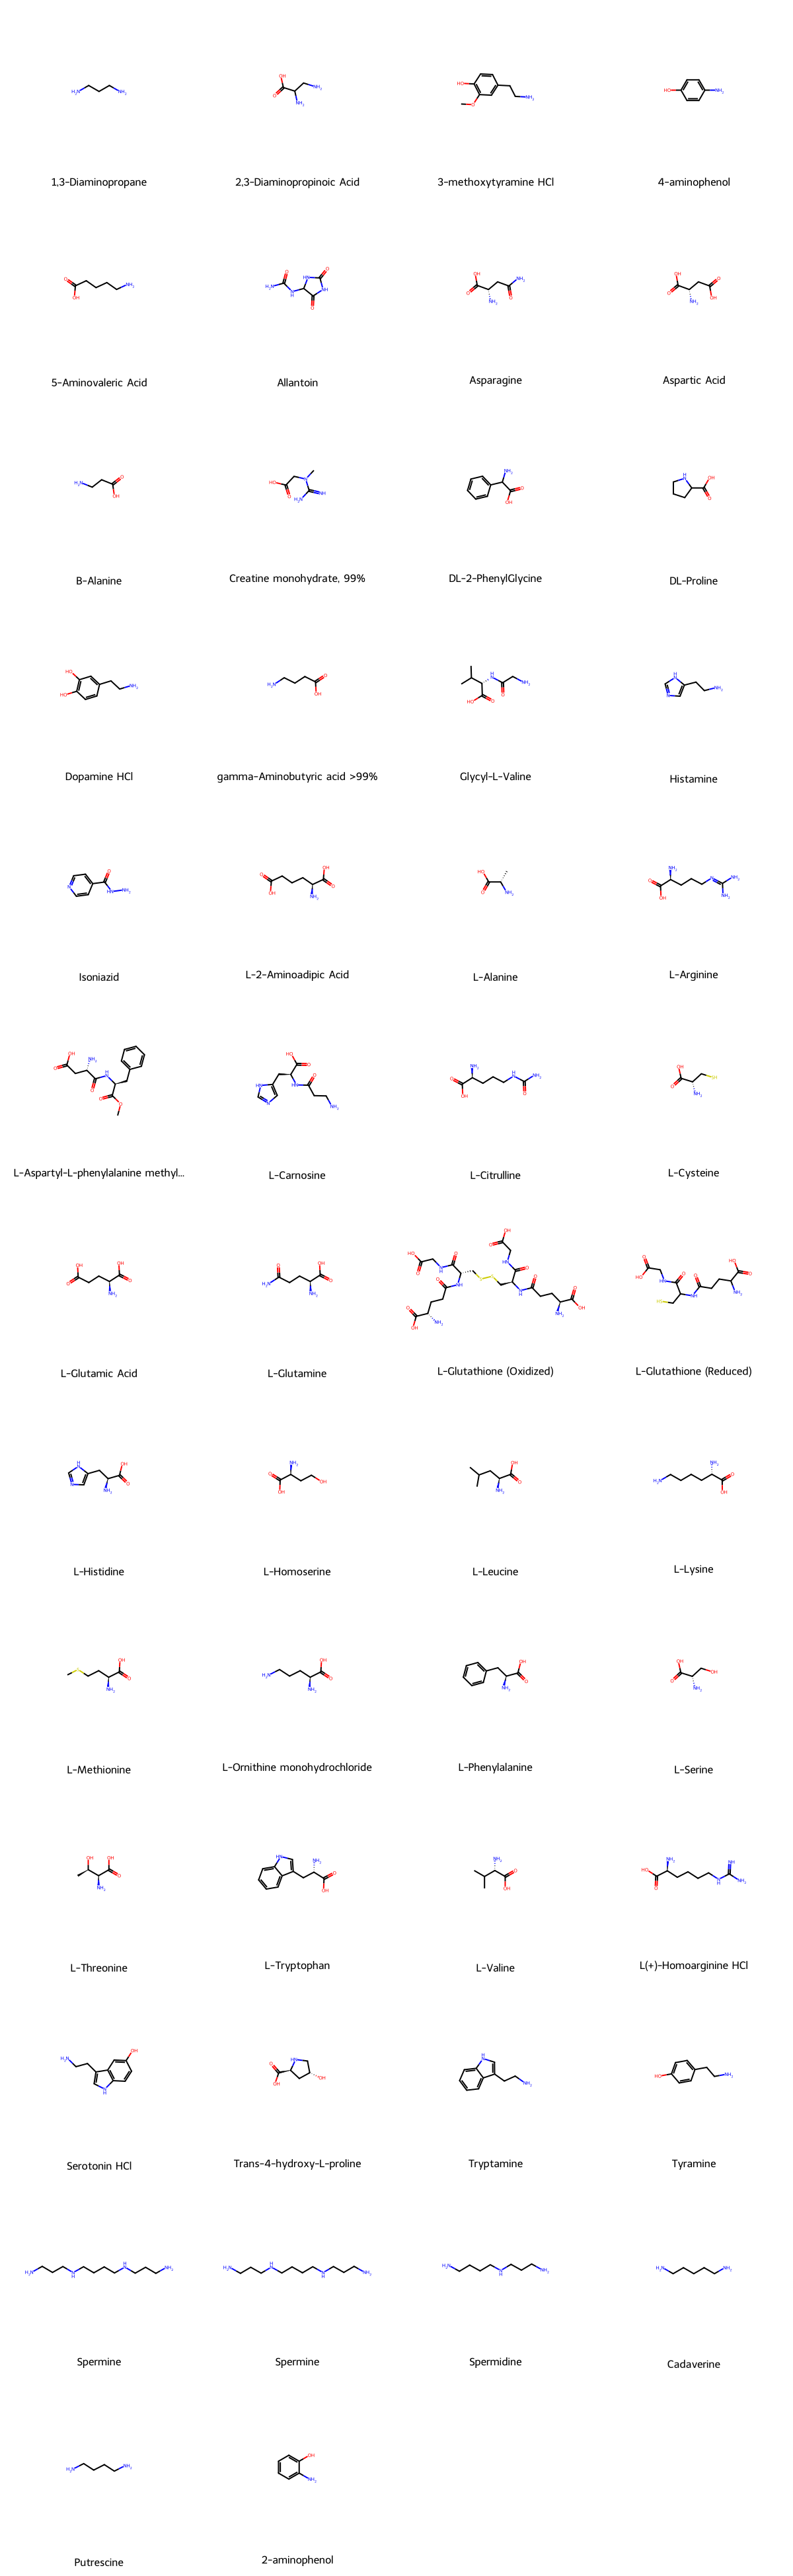

[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Running LargestFragmentChooser
[15:43:27] Running Uncharger
[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Running LargestFragmentChooser
[15:43:27] Running Uncharger
[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Running LargestFragmentChooser
[15:43:27] Running Uncharger
[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initi

Bile acids (standardized, Mono/Di/Tri)


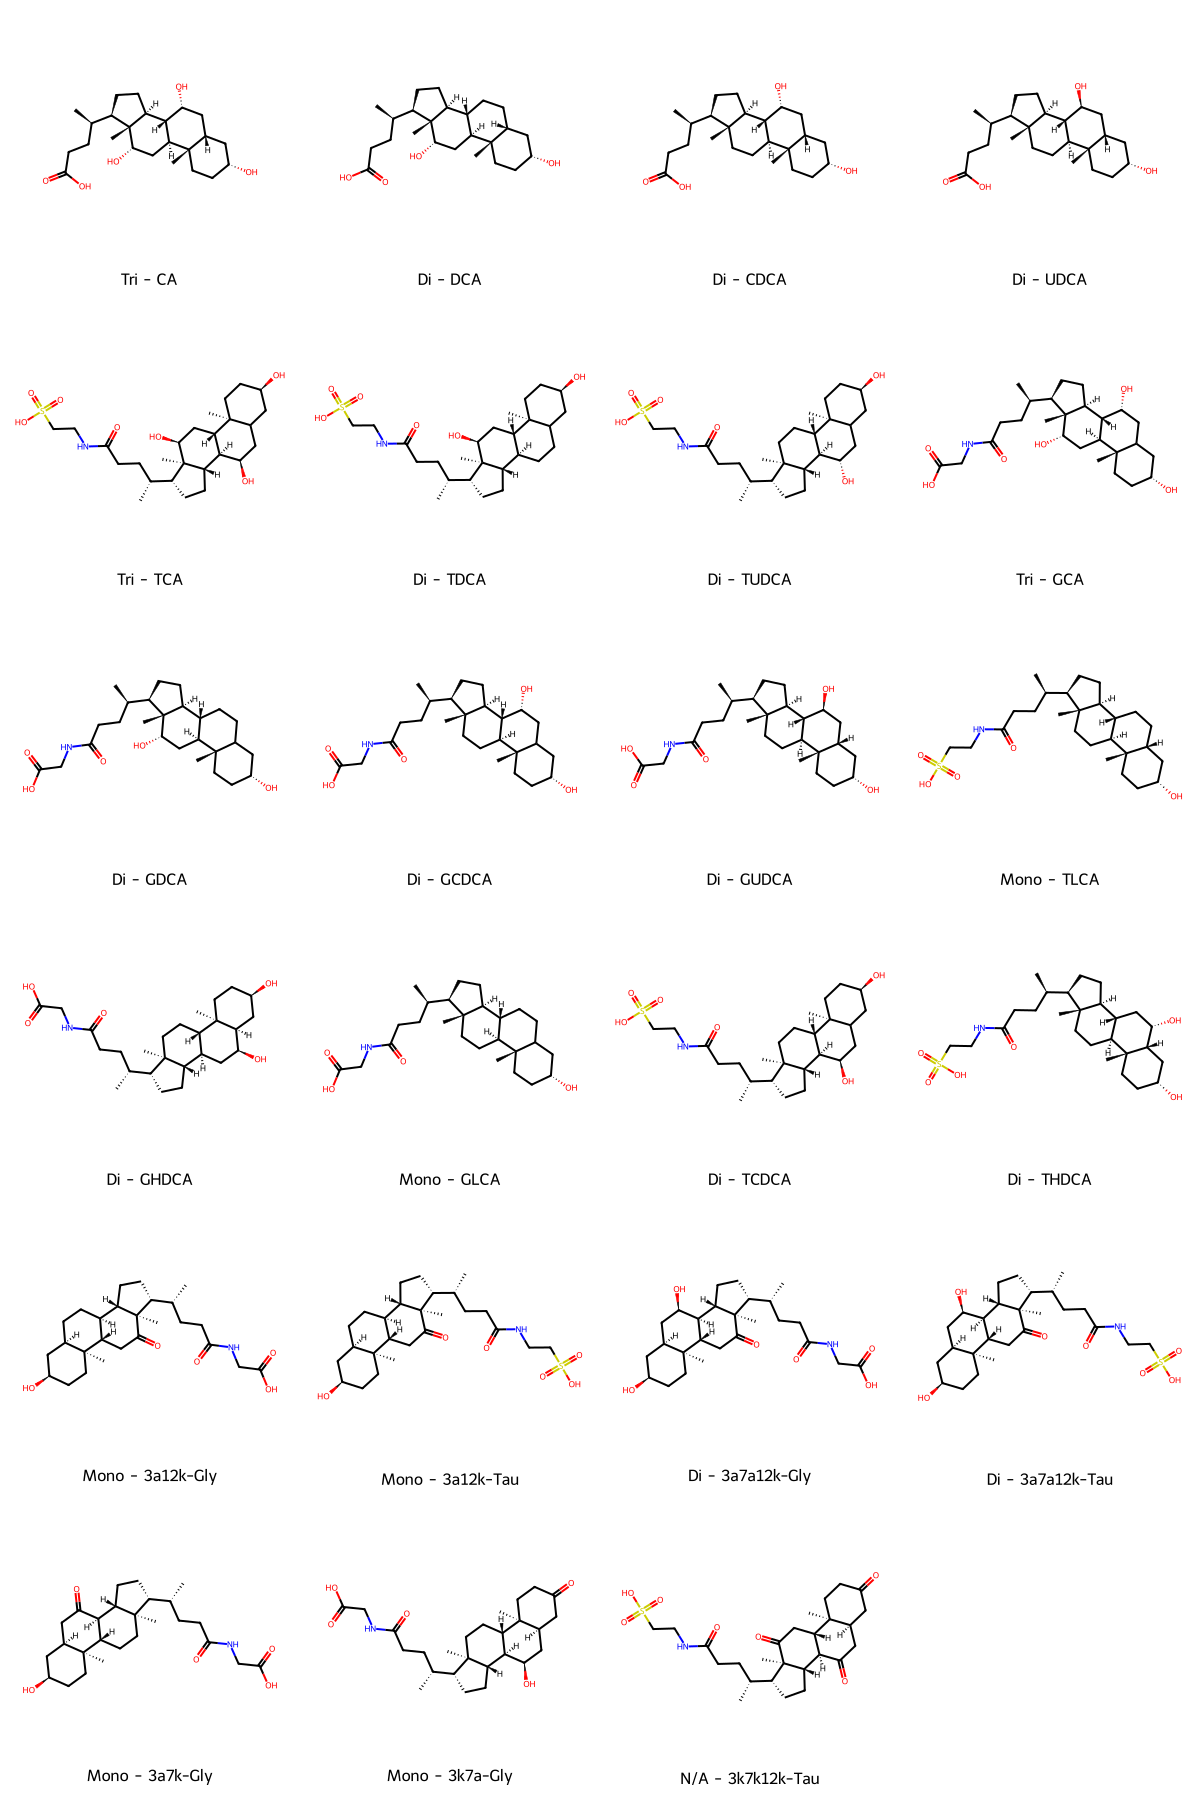

[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Running LargestFragmentChooser
[15:43:27] Running Uncharger
[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Running LargestFragmentChooser
[15:43:27] Running Uncharger
[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Running LargestFragmentChooser
[15:43:27] Fragment: Cl
[15:43:27] New largest fragment: Cl (2)
[15:43:27] Fragment: COc1cc(CCN)ccc1O
[15:43:27] New largest fragment: COc1cc(CCN)ccc1O (25)
[15:43:27] Running Uncharger
[15

Dropped rows -> Other: 0 | Bile acids: 0
Saved: ml_features_conjugation_bsh_v1.csv


[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Running LargestFragmentChooser
[15:43:27] Running Uncharger
[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Running LargestFragmentChooser
[15:43:27] Running Uncharger
[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Running LargestFragmentChooser
[15:43:27] Running Uncharger
[15:43:27] Initializing MetalDisconnector
[15:43:27] Running MetalDisconnector
[15:43:27] Initializing Normalizer
[15:43:27] Running Normalizer
[15:43:27] Initi

,Standardized_SMILES,Compound_Name,NumHDonors,NumHAcceptors,NumRotBonds,FractionCSP3,HeavyAtomCount,RingCount,AromaticRings,AliphaticRings,FormalCharge,Core_OH_Count,Bile_Core_Class,PrimaryAmines,SecondaryAmines,TertiaryAmines,Dataset
0,NCCCN,"1,3-Diaminopropane",2,2,2,1.000000,5,0,0,0,0,0,N/A,2,0,0,other
1,NCC(N)C(=O)O,"2,3-Diaminopropinoic Acid",3,3,2,0.666667,7,0,0,0,0,0,N/A,2,0,0,other
2,COc1cc(CCN)ccc1O,3-methoxytyramine HCl,2,3,3,0.333333,12,1,1,0,0,0,N/A,1,0,0,other
3,Nc1ccc(O)cc1,4-aminophenol,2,2,0,0.000000,8,1,1,0,0,0,N/A,1,0,0,other
4,NCCCCC(=O)O,5-Aminovaleric Acid,2,2,4,0.800000,8,0,0,0,0,0,N/A,1,0,0,other


In [14]:
# Column sanity (handles your exact spelling "Compount Type")
TYPE_COL = "Compount Type" if "Compount Type" in df_reactants.columns else (
    "Compound Type" if "Compound Type" in df_reactants.columns else None
)
assert TYPE_COL is not None, "Could not find 'Compount Type' (or 'Compound Type') column."
assert "SMILES" in df_reactants.columns, "Could not find 'SMILES' column."
# Compound_Name is expected from your note; if missing we’ll fall back to SMILES in legends.
HAS_NAME = "Compound_Name" in df_reactants.columns

# -----------------------------
# 2) Split into bile acids vs others
# -----------------------------
type_series = df_reactants[TYPE_COL].astype(str).str.strip()
mask_bile   = type_series.str.casefold() == "bile acid"
df_bile     = df_reactants[mask_bile].copy()
df_other    = df_reactants[~mask_bile].copy()

print(f"Total rows: {len(df_reactants)} | Bile acids: {len(df_bile)} | Other: {len(df_other)}")

# -----------------------------
# 3) Visualization (your workflow, standardized)
# -----------------------------
def _clip(s, n=36):
    s = str(s)
    return s if len(s) <= n else s[:n-3] + "..."

def _prep_valid(df, name_col="Compound_Name"):
    # parse + standardize
    df = df.copy()
    df["Mol_raw"] = df["SMILES"].apply(safe_mol)
    df["Mol"]     = df["Mol_raw"].apply(standardize_mol)
    valid = df[df["Mol"].notnull()].copy()
    valid["Standardized_SMILES"] = valid["Mol"].apply(smiles_canonical)
    # legends
    if name_col in valid.columns:
        legends = valid[name_col].astype(str).apply(_clip).tolist()
    else:
        legends = valid["Standardized_SMILES"].apply(_clip).tolist()
    return valid, legends

# --- Other (amines/others) grid ---
valid_other, legends_other = _prep_valid(df_other, name_col="Compound_Name")
img_other = Draw.MolsToGridImage(
    valid_other["Mol"].tolist(), molsPerRow=4, subImgSize=(300, 300),
    legends=legends_other, useSVG=False
)
print("Other substrates (standardized)")
display(img_other)

# --- Bile acids grid with Mono/Di/Tri label in the legend ---
valid_bile, _ = _prep_valid(df_bile, name_col="Compound_Name")
valid_bile["Hydroxylation_Class"] = valid_bile["Mol"].apply(classify_bile_acid_ignore_ketone)
name_or_smiles = (
    valid_bile["Compound_Name"].astype(str)
    if HAS_NAME else valid_bile["Standardized_SMILES"]
)
valid_bile["Legend_Label"] = (valid_bile["Hydroxylation_Class"] + " - " + name_or_smiles).apply(_clip)

img_bile = Draw.MolsToGridImage(
    valid_bile["Mol"].tolist(), molsPerRow=4, subImgSize=(300, 300),
    legends=valid_bile["Legend_Label"].tolist(), useSVG=False
)
print("Bile acids (standardized, Mono/Di/Tri)")
display(img_bile)

# -----------------------------
# 4) Build ML feature tables
# -----------------------------

# Fallback: call the base builder directly (no fingerprints first; flip include_fp=True to add FP_0..FP_1023)
features_other, dropped_other = build_feature_table(
    df_other, smiles_col="SMILES",
    name_col=("Compound_Name" if HAS_NAME else None),
    include_fp=False, nBits=1024
)
features_other["Dataset"] = "other"

features_bile, dropped_bile = build_feature_table(
    df_bile, smiles_col="SMILES",
    name_col=("Compound_Name" if HAS_NAME else None),
    include_fp=False, nBits=1024
)
features_bile["Dataset"] = "bile_acids"

print(f"Dropped rows -> Other: {len(dropped_other)} | Bile acids: {len(dropped_bile)}")

# -----------------------------
# 5) Save a single clean table for modeling
# -----------------------------
features_all = pd.concat([features_other, features_bile], ignore_index=True)
out_path = "ml_features_conjugation_bsh_v1.csv"
features_all.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
features_all.head()


Rows: total=75 | bile_acids=23 | amines=52


[15:43:58] Initializing MetalDisconnector
[15:43:58] Running MetalDisconnector
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Running LargestFragmentChooser
[15:43:58] Running Uncharger
[15:43:58] Initializing MetalDisconnector
[15:43:58] Running MetalDisconnector
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Running LargestFragmentChooser
[15:43:58] Running Uncharger
[15:43:58] Initializing MetalDisconnector
[15:43:58] Running MetalDisconnector
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Running LargestFragmentChooser
[15:43:58] Fragment: Cl
[15:43:58] New largest fragment: Cl (2)
[15:43:58] Fragment: COc1cc(CCN)ccc1O
[15:43:58] New largest fragment: COc1cc(CCN)ccc1O (25)
[15:43:58] Running Uncharger
[15

Amines (standardized)


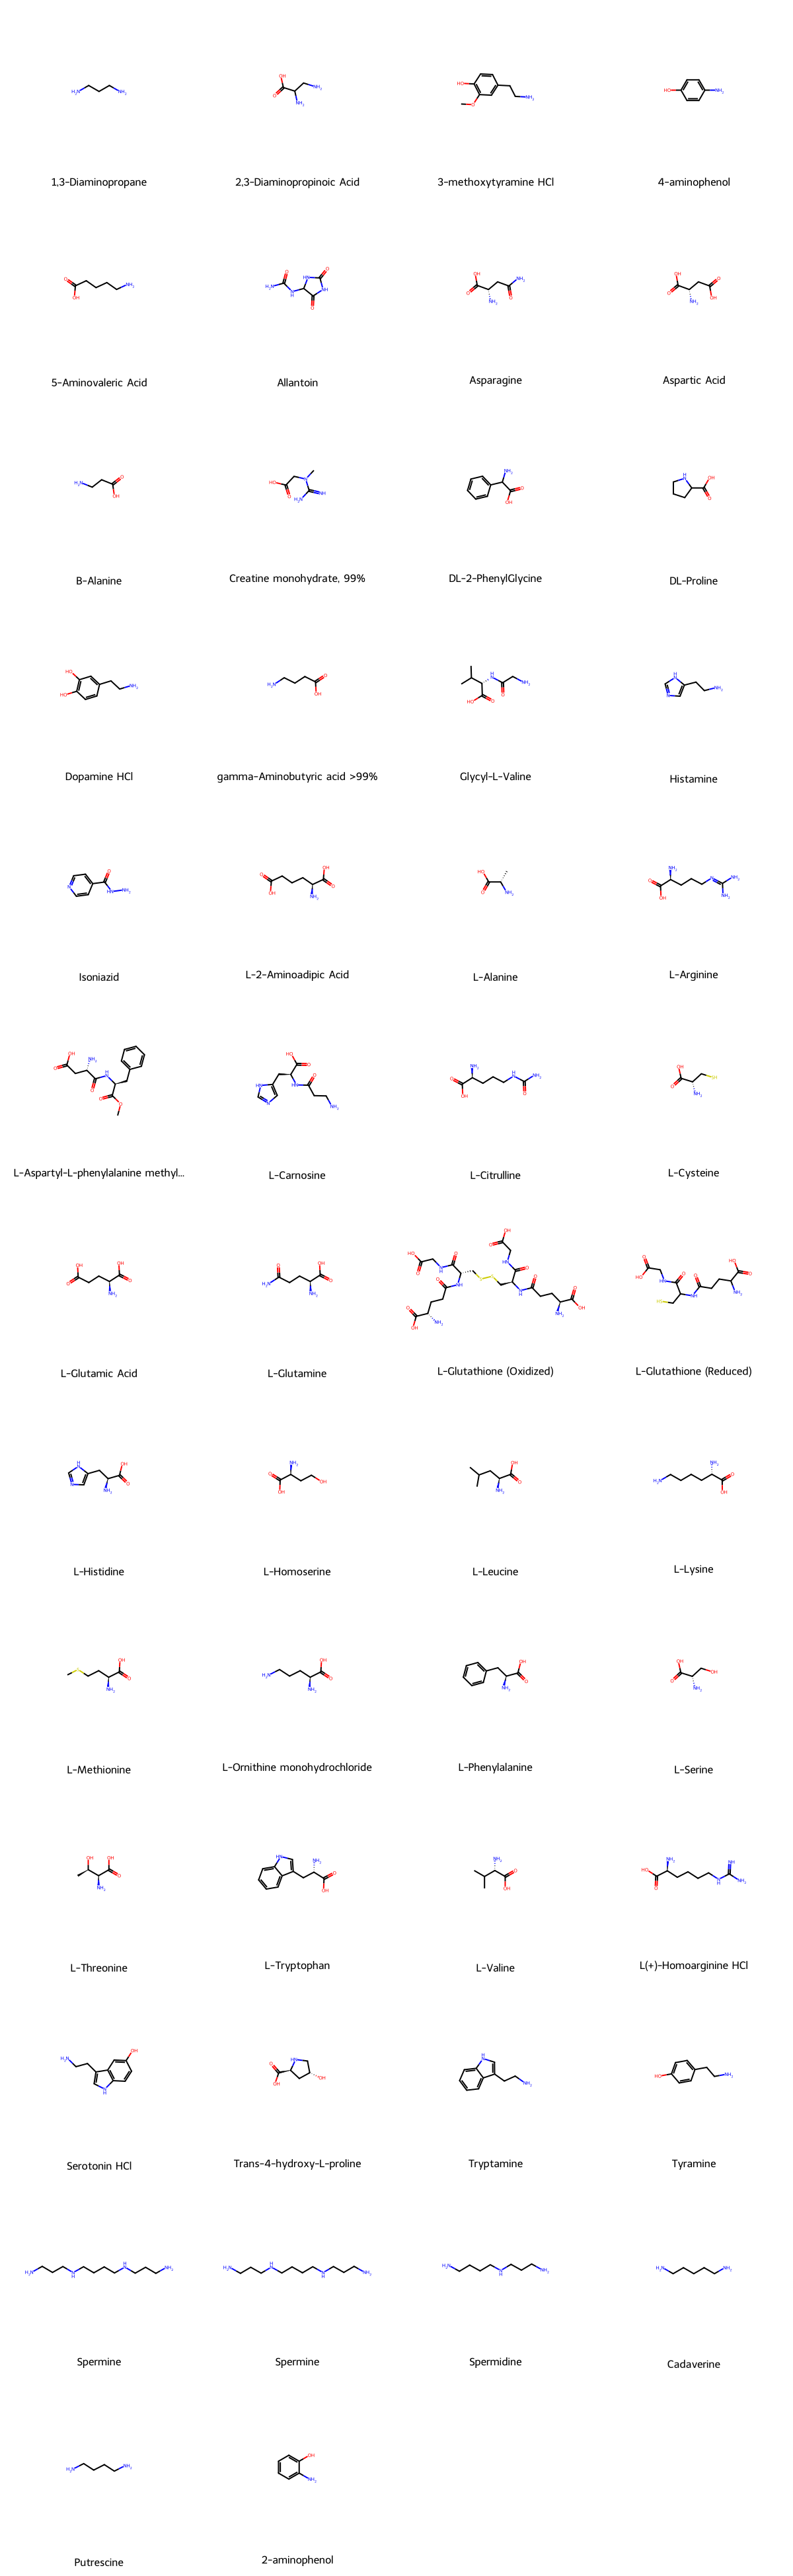

[15:43:58] Initializing MetalDisconnector
[15:43:58] Running MetalDisconnector
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Running LargestFragmentChooser
[15:43:58] Running Uncharger
[15:43:58] Initializing MetalDisconnector
[15:43:58] Running MetalDisconnector
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Running LargestFragmentChooser
[15:43:58] Running Uncharger
[15:43:58] Initializing MetalDisconnector
[15:43:58] Running MetalDisconnector
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Running LargestFragmentChooser
[15:43:58] Running Uncharger
[15:43:58] Initializing MetalDisconnector
[15:43:58] Running MetalDisconnector
[15:43:58] Initializing Normalizer
[15:43:58] Running Normalizer
[15:43:58] Initi

Bile Acids (standardized; Hydroxylation class)


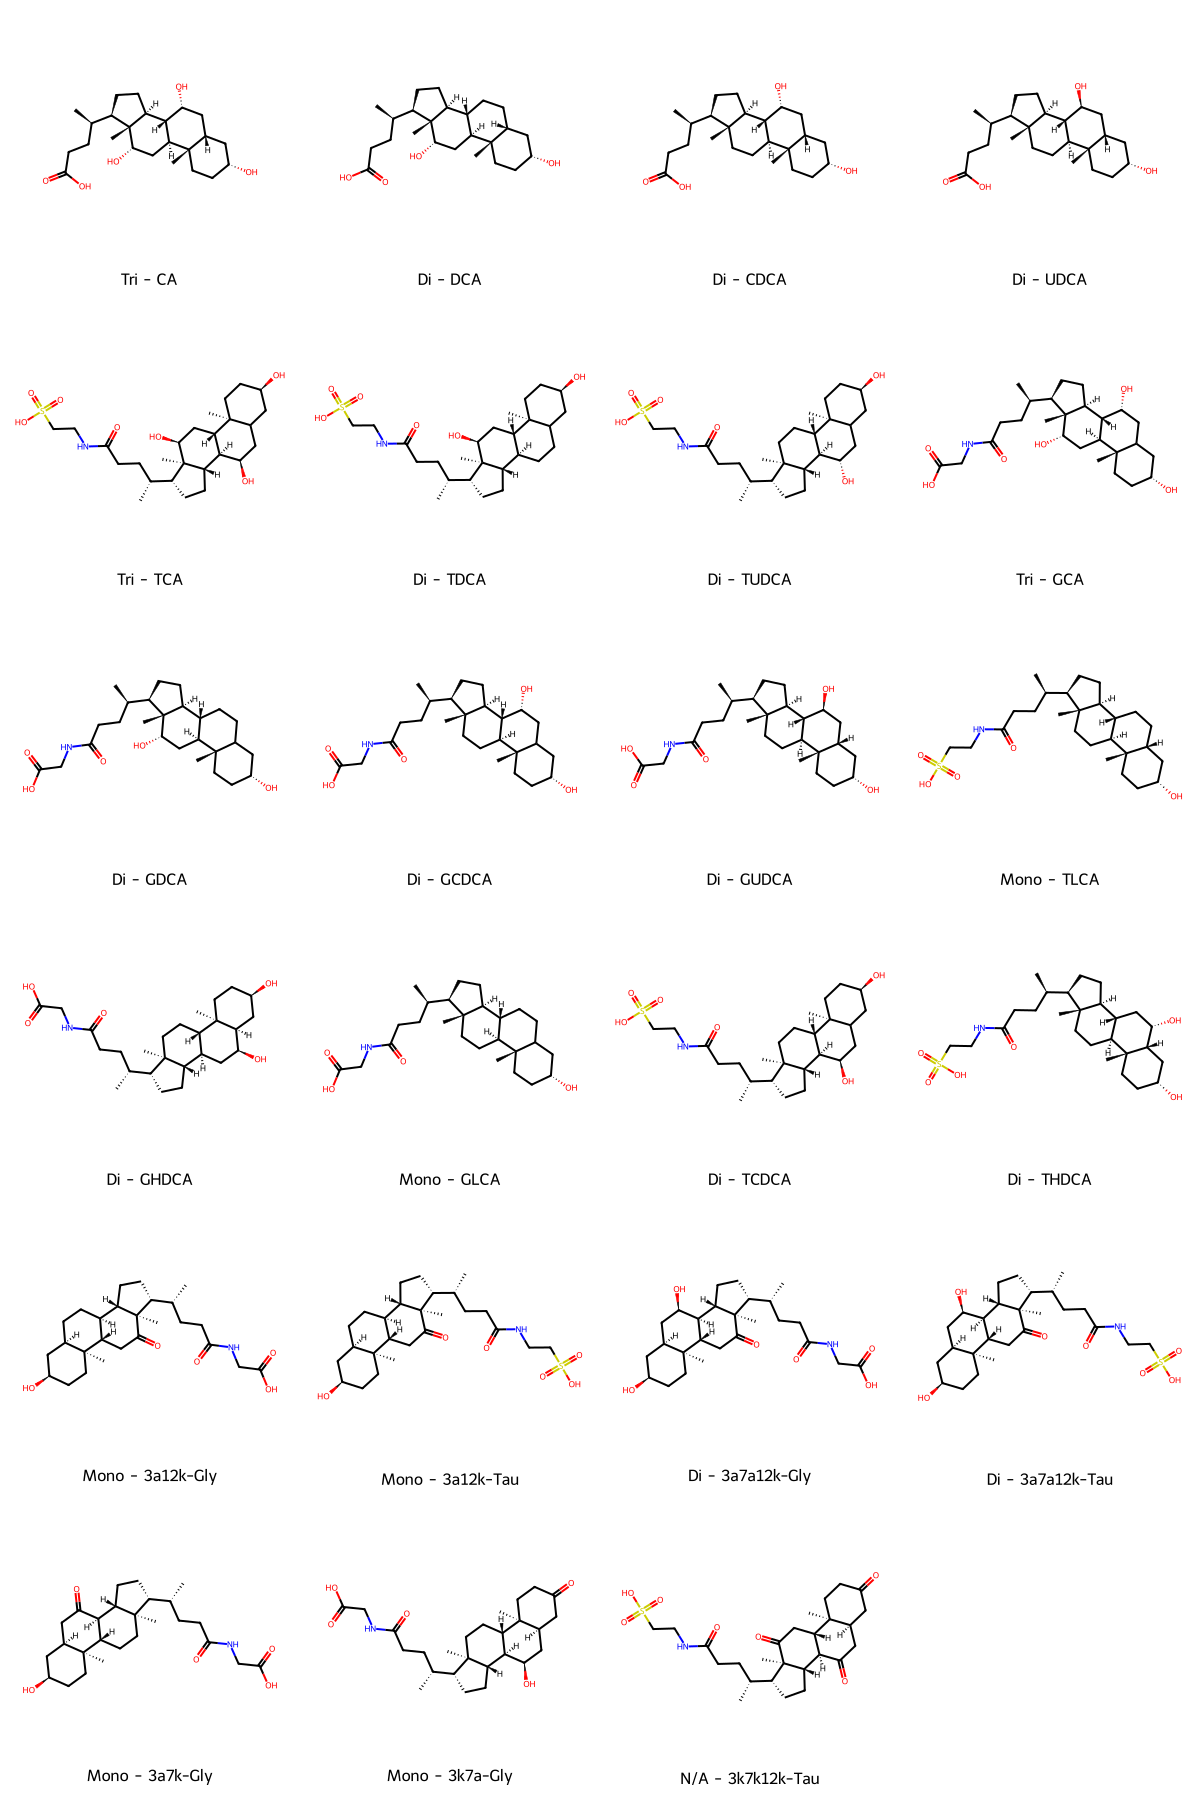

In [15]:
# --- helpers ---
def safe_mol(smiles):
    try:
        return Chem.MolFromSmiles(str(smiles).strip())
    except Exception:
        return None

def standardize_mol(mol):
    """Normalize/reionize/uncharge/keep largest fragment; fall back to sanitize-only."""
    if mol is None:
        return None
    try:
        rdMolStandardize.Cleanup(mol)
        mol = rdMolStandardize.Normalizer().normalize(mol)
        mol = rdMolStandardize.Reionizer().reionize(mol)
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)
        mol = SaltRemover().StripMol(mol, dontRemoveEverything=True)
        Chem.SanitizeMol(mol)
        mol = RemoveHs(mol)
        return mol
    except Exception:
        try:
            Chem.SanitizeMol(mol)
            return mol
        except Exception:
            return None

def smiles_canonical(mol):
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True) if mol else None

# Bile-acid hydroxylation classifier (ignore side-chain COOH)
oh_pattern   = Chem.MolFromSmarts('[CX4][OX2H]')     # OH on saturated C
cooh_pattern = Chem.MolFromSmarts('C(=O)[O;H1]')     # terminal COOH

def count_core_hydroxyls(mol):
    if mol is None:
        return 0
    oh_matches   = mol.GetSubstructMatches(oh_pattern)
    cooh_matches = mol.GetSubstructMatches(cooh_pattern)
    cooh_atoms   = {idx for m in cooh_matches for idx in m}
    count = 0
    for m in oh_matches:
        oh_idx = m[1]
        if not any(len(GetShortestPath(mol, oh_idx, c_idx)) <= 3 for c_idx in cooh_atoms):
            count += 1
    return count

def classify_bile_acid_ignore_ketone(mol):
    core_oh = count_core_hydroxyls(mol) if mol else 0
    if core_oh <= 0: return "N/A"
    if core_oh == 1: return "Mono"
    if core_oh == 2: return "Di"
    return "Tri"

def _clip(s, n=36):
    s = str(s)
    return s if len(s) <= n else s[:n-3] + "..."

def _prep_valid(df):
    df = df.copy()
    df["Mol_raw"] = df["SMILES"].apply(safe_mol)
    df["Mol"]     = df["Mol_raw"].apply(standardize_mol)
    valid = df[df["Mol"].notnull()].copy()
    valid["Standardized_SMILES"] = valid["Mol"].apply(smiles_canonical)
    return valid

# --- load your data ---
df = pd.read_excel("bsh_reactants_SMILES.xlsx")
TYPE_COL = "Compount Type" if "Compount Type" in df.columns else (
    "Compound Type" if "Compound Type" in df.columns else None
)
assert TYPE_COL is not None, "Missing 'Compount Type' (or 'Compound Type') column."
assert "SMILES" in df.columns, "Missing 'SMILES' column."
has_name = "Compound_Name" in df.columns

# --- split: bile acids vs amines ---
t = df[TYPE_COL].astype(str).str.strip().str.casefold()
mask_bile  = t == "bile acid"
# robust amine matching
mask_amine = t.isin({"amine", "amines", "amine substrate"}) | t.str.contains("amine", na=False)

df_bile   = df[mask_bile].copy()
df_amines = df[mask_amine].copy()

print(f"Rows: total={len(df)} | bile_acids={len(df_bile)} | amines={len(df_amines)}")

# --- visualize AMINES ---
valid_amines = _prep_valid(df_amines)
leg_amines = (
    valid_amines["Compound_Name"].astype(str)
    if has_name else valid_amines["Standardized_SMILES"]
).apply(_clip)

print("Amines (standardized)")
img_amines = Draw.MolsToGridImage(
    valid_amines["Mol"].tolist(),
    molsPerRow=4, subImgSize=(300,300),
    legends=leg_amines.tolist(),
    useSVG=False
)
display(img_amines)

# --- visualize BILE ACIDS (with Mono/Di/Tri in legend) ---
valid_bile = _prep_valid(df_bile)
valid_bile["Hydroxylation_Class"] = valid_bile["Mol"].apply(classify_bile_acid_ignore_ketone)
name_or_smiles = (
    valid_bile["Compound_Name"].astype(str)
    if has_name else valid_bile["Standardized_SMILES"]
)
leg_bile = (valid_bile["Hydroxylation_Class"] + " - " + name_or_smiles).apply(_clip)

print("Bile Acids (standardized; Hydroxylation class)")
img_bile = Draw.MolsToGridImage(
    valid_bile["Mol"].tolist(),
    molsPerRow=4, subImgSize=(300,300),
    legends=leg_bile.tolist(),
    useSVG=False
)
display(img_bile)


Visualizing all possible products

In [16]:
features_all

,Standardized_SMILES,Compound_Name,NumHDonors,NumHAcceptors,NumRotBonds,FractionCSP3,HeavyAtomCount,RingCount,AromaticRings,AliphaticRings,FormalCharge,Core_OH_Count,Bile_Core_Class,PrimaryAmines,SecondaryAmines,TertiaryAmines,Dataset
0,NCCCN,"1,3-Diaminopropane",2,2,2,1.000000,5,0,0,0,0,0,N/A,2,0,0,other
1,NCC(N)C(=O)O,"2,3-Diaminopropinoic Acid",3,3,2,0.666667,7,0,0,0,0,0,N/A,2,0,0,other
2,COc1cc(CCN)ccc1O,3-methoxytyramine HCl,2,3,3,0.333333,12,1,1,0,0,0,N/A,1,0,0,other
3,Nc1ccc(O)cc1,4-aminophenol,2,2,0,0.000000,8,1,1,0,0,0,N/A,1,0,0,other
4,NCCCCC(=O)O,5-Aminovaleric Acid,2,2,4,0.800000,8,0,0,0,0,0,N/A,1,0,0,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,C[C@H](CCC(=O)NCC(=O)O)[C@H]1CC[C@H]2[C@@H]3[C...,3a7a12k-Gly,4,5,6,0.884615,33,4,0,4,0,2,Di,0,0,0,bile_acids
71,C[C@H](CCC(=O)NCCS(=O)(=O)O)[C@H]1CC[C@H]2[C@@...,3a7a12k-Tau,4,6,7,0.923077,35,4,0,4,0,2,Di,0,0,0,bile_acids
72,C[C@H](CCC(=O)NCC(=O)O)[C@H]1CC[C@H]2[C@@H]3C(...,3a7k-Gly,3,4,6,0.884615,32,4,0,4,0,1,Mono,0,0,0,bile_acids
73,C[C@H](CCC(=O)NCC(=O)O)[C@H]1CC[C@H]2[C@@H]3[C...,3k7a-Gly,3,4,6,0.884615,32,4,0,4,0,1,Mono,0,0,0,bile_acids


#Uploading the bile acid heat map data


*   Extracting the possible product names
* There are 2 heatmaps
1.  "NEW_Stage2_BAs_amines_for_heatmap_manual.csv" for all their amine specific products
2. "NEW_Stage2_BAs_subs_for_heatmap_manual.csv"for all their other amine-containing substitutes eg. amino acids

In their heat map the **y-axis** contains the name of the protein ID, while the **x-axis** is the name of the products (conjugated- amine x bile acid)





In [18]:
df_results_amines = pd.read_csv("NEW_Stage2_BAs_amines_for_heatmap_manual.csv")
df_results_sub = pd.read_csv("NEW_Stage2_BAs_subs_for_heatmap_manual.csv")

# Define metadata columns to exclude
meta_cols = ['Code', 'Replicate',"filename"]

# Select only product columns
product_cols_amines = [col for col in df_results_amines.columns if col not in meta_cols]
product_cols_sub = [col for col in df_results_sub.columns if col not in meta_cols]

print("Amine product columns:", product_cols_amines[:10])  # preview first 10
print("Substituent product columns:", product_cols_sub[:10])


Amine product columns: ['Di_2,3_diaminopropionic acid_14073', 'Tri_2,3_diaminopropionic acid_14940', 'Di_ornithine_15391', 'Tri_ornithine_17210', 'Tri_histidine_17315', 'Tri_2,3_diaminopropionic acid_17863', 'Tri_2,3_diaminopropionic acid_17869', 'Di_ornithine_17963', 'Tri_arginine_18281', 'Tri_2,3_diaminopropionic acid_18373']
Substituent product columns: ['3a7a12k_taurine_14542', 'Di_taurine_19595', 'Tri_taurine_20369', '3a12k_taurine_22309', 'Tri_glycine_25947', 'Di_glycine_27361', 'Di_taurine_29331', 'Di_taurine_30261', 'Di_glycine_34166', 'Di_glycine_34738']


In [19]:
# Step 1: Define metadata columns to exclude
meta_cols = ['Code', 'Replicate', 'filename']

# Step 2: Get all product columns from both amine and substituent tables
product_cols_amines = [col for col in df_results_amines.columns if col not in meta_cols]
product_cols_sub = [col for col in df_results_sub.columns if col not in meta_cols]

# Step 3: Combine all product names and get the unique ones
all_product_names = pd.Series(product_cols_amines + product_cols_sub).drop_duplicates().sort_values().reset_index(drop=True)

# Step 4: Save to Excel
unique_products_df = pd.DataFrame({'Unique_ProductNames': all_product_names})
unique_products_df.to_excel("unique_conjugated_products.xlsx", index=False)

print(f"✅ Saved {len(unique_products_df)} unique product names to 'unique_conjugated_products.xlsx'")



✅ Saved 94 unique product names to 'unique_conjugated_products.xlsx'


In [20]:
unique_products_df

,Unique_ProductNames
0,"3a,7a,12k_alanine_20366"
1,"3a,7a,12k_lysine_23168"
2,3a12k_serine_27652
3,3a12k_taurine_22309
4,3a7a12k_taurine_14542
...,...
89,Tri_proline_M+NH4_18411
90,Tri_putrescine_18433
91,Tri_serine_23158
92,Tri_taurine_20369


#creating a combinatorial table of all possible conjugation pairs

RUN DOWN OF THE SCRIPT

1. Parses each product name, specifically through hydroxylation class (Mono/Di/Tri) or a position “3a7b”
2. it builds two parent pools from features_all free
acids (unconjugated BA set), pre-conjugates (already conjugated with taurine/glycine)
3. hydrolysis: pre-conjugated BA → free acid (cuts the amide)
4. decision tree for every product type, creating a list of all possible options.

LATER WILL BE USED IN:
substrates_catalog_pairs.csv — one row per candidate pair with:

In [24]:
# =========================
# 1) Structural conjugation detection (TAU/GLY)
# =========================
amide_any      = Chem.MolFromSmarts('C(=O)N')                   # generic amide
taurine_tail   = Chem.MolFromSmarts('NCCS(=O)(=O)[O-,$([OH])]') # taurine tail
glycine_tail   = Chem.MolFromSmarts('NCC(=O)[O-,$([OH])]')      # glycine tail
cooh_carb      = Chem.MolFromSmarts('C(=O)[O-,$([OH])]')        # COOH carbonyl

def is_bile_conjugated(mol):
    """
    Returns (is_conj:int, conj_type:str) with conj_type in {'TAU','GLY','UNKNOWN','NONE'}
    Localizes the amide to the side-chain COOH region by proximity (<=3 bonds) to carbonyl carbon.
    """
    if mol is None:
        return 0, 'NONE'

    amides = mol.GetSubstructMatches(amide_any)
    coohs  = mol.GetSubstructMatches(cooh_carb)
    if not amides or not coohs:
        return 0, 'NONE'

    cooh_c_atoms = {m[0] for m in coohs}  # carbonyl carbon indices
    candidate = []
    for a in amides:
        c_idx = a[0]  # carbonyl carbon in C(=O)N
        if any(len(rdmolops.GetShortestPath(mol, c_idx, c2)) <= 3 for c2 in cooh_c_atoms):
            candidate.append(a)
    if not candidate:
        return 0, 'NONE'

    if mol.HasSubstructMatch(taurine_tail):
        return 1, 'TAU'
    if mol.HasSubstructMatch(glycine_tail):
        return 1, 'GLY'
    return 1, 'UNKNOWN'

# =========================
# 2) Feature builder (adds conjugation flags)
# =========================
def compute_features_for_mol(mol, include_fp=True, nBits=1024):
    feats = {k: (np.nan if mol is None else DESC_FUNCS[k](mol)) for k in DESC_FUNCS}
    feats['FormalCharge'] = formal_charge(mol)
    feats['Core_OH_Count']   = (np.nan if mol is None else count_core_hydroxyls(mol))
    feats['Bile_Core_Class'] = ('N/A' if mol is None else classify_bile_acid_ignore_ketone(mol))
    p,s,t = amine_counts(mol)
    feats['PrimaryAmines'], feats['SecondaryAmines'], feats['TertiaryAmines'] = p,s,t

    if mol is None:
        feats['IsConjugated_SMARTS'] = np.nan
        feats['ConjugationType_SMARTS'] = 'N/A'
    else:
        is_c, ctype = is_bile_conjugated(mol)
        feats['IsConjugated_SMARTS'] = int(is_c)
        feats['ConjugationType_SMARTS'] = ctype

    if include_fp:
        fp = morgan_fp_bits(mol, radius=2, nBits=nBits)
        feats.update({f'FP_{i}': int(fp[i]) for i in range(nBits)})
    return feats

def build_feature_table(df, smiles_col='SMILES', name_col=None, include_fp=False, nBits=1024):
    work = df.copy()
    work['Original_SMILES'] = work[smiles_col]
    work['Mol_raw'] = work[smiles_col].apply(safe_mol)
    work['Mol']     = work['Mol_raw'].apply(standardize_mol)
    work['Standardized_SMILES'] = work['Mol'].apply(smiles_canonical)

    valid_mask  = work['Mol'].notnull()
    dropped_idx = work.index[~valid_mask].tolist()

    feat_rows = [compute_features_for_mol(mol, include_fp=include_fp, nBits=nBits)
                 for mol in work.loc[valid_mask, 'Mol']]
    features_df = pd.DataFrame(feat_rows, index=work.index[valid_mask])

    keep_cols = ['Original_SMILES', 'Standardized_SMILES']
    if name_col and name_col in work.columns:
        keep_cols.append(name_col)
    meta = work.loc[valid_mask, keep_cols]

    features_df = pd.concat([meta, features_df], axis=1).reset_index(drop=True)
    return features_df, dropped_idx

# =========================
# 3) Name-based inference with -Gly / -Tau + exact SMILES
# =========================
TAURINE_NAME_ALIASES = {"TAU", "TAURINE", "TAURO"}
GLYCINE_NAME_ALIASES = {"GLY", "GLYCINE", "GLYCO"}

TAURINE_SMILES = "OS(=O)(CCN)=O"
GLYCINE_SMILES = "NCC(O)=O"

BASES = ["UDCA","CDCA","HDCA","DCA","LCA","CA"]

def _strip_accents(s: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def _clean_name(x) -> str:
    if pd.isna(x): return ""
    s = _strip_accents(str(x)).upper()
    s = re.sub(r"[\s_]+", "-", s)
    return re.sub(r"[^A-Z0-9\-]", "", s)

def _infer_conjugation_and_base_advanced(name: str):
    s = _clean_name(name)
    conj_label, conj_smiles, base_code = None, None, None
    m = re.search(r"-(GLY|TAU)$", s)
    if m:
        tag = m.group(1)
        if tag == "GLY": conj_label, conj_smiles = "Glycine", GLYCINE_SMILES
        elif tag == "TAU": conj_label, conj_smiles = "Taurine", TAURINE_SMILES
    if conj_label is None:
        if any(alias in s for alias in TAURINE_NAME_ALIASES):
            conj_label, conj_smiles = "Taurine", TAURINE_SMILES
        elif any(alias in s for alias in GLYCINE_NAME_ALIASES):
            conj_label, conj_smiles = "Glycine", GLYCINE_SMILES
    if conj_label is None:
        for b in BASES:
            if f"T{b}" in s: conj_label, conj_smiles, base_code = "Taurine", TAURINE_SMILES, b; break
            if f"G{b}" in s: conj_label, conj_smiles, base_code = "Glycine", GLYCINE_SMILES, b; break
    if base_code is None:
        for b in BASES:
            if b in s: base_code = b; break
    return conj_label, conj_smiles, base_code

# =========================
# 4) Build features_all (STRUCTURE first; names fallback)
# =========================
# Load reactants sheet
df_reactants = pd.read_excel("bsh_reactants_SMILES.xlsx")
TYPE_COL = "Compount Type" if "Compount Type" in df_reactants.columns else (
    "Compound Type" if "Compound Type" in df_reactants.columns else None
)
assert TYPE_COL is not None, "Missing 'Compount Type' (or 'Compound Type') column."
assert "SMILES" in df_reactants.columns, "Missing 'SMILES' column."
HAS_NAME = "Compound_Name" in df_reactants.columns

t = df_reactants[TYPE_COL].astype(str).str.strip().str.casefold()
mask_bile  = (t == "bile acid")
mask_amine = t.isin({"amine", "amines", "amine substrate"}) | t.str.contains("amine", na=False)

df_bile   = df_reactants[mask_bile].copy()
df_amines = df_reactants[mask_amine].copy()

features_amines, dropped_amines = build_feature_table(
    df_amines, smiles_col="SMILES", name_col=("Compound_Name" if HAS_NAME else None),
    include_fp=False, nBits=1024
)
features_amines["Dataset"] = "amines"

features_bile, dropped_bile = build_feature_table(
    df_bile, smiles_col="SMILES", name_col=("Compound_Name" if HAS_NAME else None),
    include_fp=False, nBits=1024
)
features_bile["Dataset"] = "bile_acids"

# Name-based add-ons for bile acids
if HAS_NAME and "Compound_Name" in features_bile.columns:
    conj_labels, conj_smiles, base_names = zip(*[
        _infer_conjugation_and_base_advanced(nm) for nm in features_bile["Compound_Name"].tolist()
    ])
    features_bile["Conjugated_Amine_Name"]   = list(conj_labels)
    features_bile["Conjugated_Amine_SMILES"] = list(conj_smiles)
    features_bile["Base_Acid_From_Name"]     = list(base_names)
    features_bile["Is_Conjugated_From_Name"] = features_bile["Conjugated_Amine_Name"].notna()
else:
    features_bile["Conjugated_Amine_Name"]   = None
    features_bile["Conjugated_Amine_SMILES"] = None
    features_bile["Base_Acid_From_Name"]     = None
    features_bile["Is_Conjugated_From_Name"] = False

# Final harmonized conjugation call (prefer structure)
def _final_conj_label(row):
    ctype = row.get("ConjugationType_SMARTS", "N/A")
    if ctype in ("TAU", "GLY", "UNKNOWN"):
        return {"TAU":"Taurine", "GLY":"Glycine", "UNKNOWN":"Unknown"}[ctype]
    nm = row.get("Conjugated_Amine_Name", None)
    return nm if pd.notna(nm) and nm else "None"

def _final_conj_smiles(row):
    ctype = row.get("ConjugationType_SMARTS", "N/A")
    if ctype == "TAU": return TAURINE_SMILES
    if ctype == "GLY": return GLYCINE_SMILES
    return row.get("Conjugated_Amine_SMILES", None)

features_bile["IsConjugated_Final"] = features_bile["IsConjugated_SMARTS"].fillna(0).astype(int)
features_bile.loc[
    features_bile["IsConjugated_Final"].eq(0) & features_bile["Is_Conjugated_From_Name"],
    "IsConjugated_Final"
] = 1
features_bile["ConjugationType_Final"]          = features_bile.apply(_final_conj_label,  axis=1)
features_bile["Conjugated_Amine_SMILES_Final"]  = features_bile.apply(_final_conj_smiles, axis=1)

features_all = pd.concat([features_amines, features_bile], ignore_index=True)

# Save features_all (so we can inspect independently)
out_xlsx = "ml_features_conjugation_bsh_FINAL.xlsx"
# order columns (compact)
front_cols = [c for c in [
    "Compound_Name", "Dataset",
    "Original_SMILES", "Standardized_SMILES",
    "IsConjugated_Final", "ConjugationType_Final", "Conjugated_Amine_SMILES_Final",
    "IsConjugated_SMARTS", "ConjugationType_SMARTS",
    "Is_Conjugated_From_Name", "Conjugated_Amine_Name", "Conjugated_Amine_SMILES", "Base_Acid_From_Name",
    "Core_OH_Count", "Bile_Core_Class",
    "PrimaryAmines", "SecondaryAmines", "TertiaryAmines",
] if c in features_all.columns]
desc_cols = [c for c in [
    "MolWt","LogP","TPSA","NumHDonors","NumHAcceptors","NumRotBonds",
    "FractionCSP3","HeavyAtomCount","RingCount","AromaticRings","AliphaticRings",
    "FormalCharge","NumValenceElectrons"
] if c in features_all.columns]
fp_cols = [c for c in features_all.columns if c.startswith("FP_")]
other_cols = [c for c in features_all.columns if c not in set(front_cols + desc_cols + fp_cols)]
features_all = features_all[front_cols + desc_cols + other_cols + fp_cols]
features_all.to_excel(out_xlsx, index=False)
print(f"Saved features: {out_xlsx}")

# =========================
# 5) Product list (from your heatmaps) → prod_df
# =========================
# Load or reuse all_product_names
def _load_features_all():
    if "features_all" in globals():
        return globals()["features_all"].copy()
    if os.path.exists("ml_features_conjugation_bsh_FINAL.xlsx"):
        x = pd.ExcelFile("ml_features_conjugation_bsh_FINAL.xlsx"); sh = "All" if "All" in x.sheet_names else x.sheet_names[0]
        return pd.read_excel("ml_features_conjugation_bsh_FINAL.xlsx", sheet_name=sh)
    raise FileNotFoundError("features_all not found on disk.")

fa_all = _load_features_all()

# If you already loaded df_results_amines / df_results_sub, reuse them; else read defaults
if 'all_product_names' not in globals():
    df_results_amines = pd.read_csv("NEW_Stage2_BAs_amines_for_heatmap_manual.csv")
    df_results_sub    = pd.read_csv("NEW_Stage2_BAs_subs_for_heatmap_manual.csv")
    meta_cols = ['Code','Replicate','filename']
    product_cols_amines = [c for c in df_results_amines.columns if c not in meta_cols]
    product_cols_sub    = [c for c in df_results_sub.columns    if c not in meta_cols]
    all_product_names   = pd.Series(product_cols_amines + product_cols_sub).drop_duplicates().sort_values().reset_index(drop=True)

# (optional) restrict to list in unique_conjugated_products.xlsx if present
UNIQUE_FILE = "unique_conjugated_products.xlsx"
allowed = None
try:
    df_unique = pd.read_excel(UNIQUE_FILE)
    unique_col = "Unique_ProductNames" if "Unique_ProductNames" in df_unique.columns else df_unique.columns[0]
    allowed = set(df_unique[unique_col].dropna().astype(str).str.strip())
    print(f"[Filter] Loaded {len(allowed)} allowed product names from '{UNIQUE_FILE}'")
except Exception:
    pass

if allowed is not None:
    all_names_clean = [str(p).strip() for p in all_product_names]
    prod_names = [p for p in all_names_clean if p in allowed]
else:
    prod_names = list(all_product_names)

# --- parsing helpers for product labels ---
def _greek_to_latin(s: str) -> str:
    s2 = s.replace('α','a').replace('β','b').replace('Α','a').replace('Β','b')
    s2 = re.sub(r'\balpha\b', 'a', s2, flags=re.I)
    s2 = re.sub(r'\bbeta\b',  'b', s2, flags=re.I)
    return s2

POS_RE_SIMPLE = re.compile(r'(\d+)\s*([abk])', re.I)

def extract_pos_key(s: str) -> str | None:
    if pd.isna(s) or not str(s).strip():
        return None
    txt = _greek_to_latin(_strip_accents(str(s))).lower()
    txt = re.sub(r'(\d+)\s*-\s*(oxo|keto|one)\b', r'\1k', txt)
    txt = re.sub(r'(\d+)\s*(oxo|keto|one)\b',     r'\1k', txt)
    hits = POS_RE_SIMPLE.findall(txt.replace(',', ' '))
    if not hits:
        return None
    return ''.join([f"{n}{l.lower()}" for (n,l) in hits])

def extract_pos_tokens(s: str) -> set[str]:
    key = extract_pos_key(s)
    if not key: return set()
    return set(re.findall(r'\d+[abk]', key))

def core_from_positional_key(pos_key: str | None) -> str | None:
    if not pos_key: return None
    letters = re.findall(r'\d+([abk])', pos_key.lower())
    n_oh = sum(1 for L in letters if L in ('a','b'))
    if n_oh >= 3: return "Tri"
    if n_oh == 2: return "Di"
    if n_oh == 1: return "Mono"
    return None

def normalize_name_salts(name):
    if pd.isna(name): return None
    s = str(name)
    s = _greek_to_latin(_strip_accents(s)).lower()
    s = re.sub(r'_m[\+\-][a-z0-9]+', '', s)
    s = re.sub(r'[_\-,]+', ' ', s)
    s = re.sub(r'\b(monohydrochloride|hydrochloride|hcl|na|k|anhydrous|monohydrate)\b', '', s)
    s = re.sub(r'^(dl|l|d)\s+', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return None if s == 'unconjugated' else s

# amine name→SMILES map via reactants sheet (with fuzzy fallback)
from difflib import SequenceMatcher
df_reactants2 = df_reactants.copy()
df_reactants2['Norm_Name'] = df_reactants2['Compound_Name'].apply(normalize_name_salts)
_norm_to_smiles = (df_reactants2.dropna(subset=['Norm_Name'])
                   .groupby('Norm_Name')['SMILES']
                   .apply(lambda s: next((x for x in s if pd.notna(x) and str(x).strip()), None)).to_dict())
_norm_to_orig   = (df_reactants2.dropna(subset=['Norm_Name'])
                   .groupby('Norm_Name')['Compound_Name'].first().to_dict())
_norm_keys = list(_norm_to_orig.keys())

def best_norm_lookup(name_norm: str):
    if not name_norm: return (None, None)
    if name_norm in _norm_to_smiles:
        return _norm_to_orig[name_norm], _norm_to_smiles[name_norm]
    best, best_score = None, 0.0
    for cand in _norm_keys:
        sc = SequenceMatcher(None, name_norm, cand).ratio()
        if sc >= 0.90 and sc > best_score:
            best, best_score = cand, sc
    if best:
        return _norm_to_orig.get(best), _norm_to_smiles.get(best)
    return (None, None)

AMINE_ALIASES = {
    "gaba": [
        "gamma-aminobutyric acid","gamma aminobutyric acid",
        "4-aminobutyric acid","4-aminobutanoic acid",
        "aminobutyric acid","aminobutanoic acid",
    ],
}
def best_norm_lookup_aliased(name_norm: str):
    o, s = best_norm_lookup(name_norm)
    if s: return o, s
    key = (name_norm or "").strip().lower()
    if key in AMINE_ALIASES:
        for human in AMINE_ALIASES[key]:
            alt_norm = normalize_name_salts(human)
            o2, s2 = best_norm_lookup(alt_norm)
            if s2:
                return o2, s2
    return (None, None)

def _parse_product_label_POS_FIRST(lbl):
    if pd.isna(lbl):
        return None, None, None, None
    parts = str(lbl).strip().split('_')
    head  = parts[0] if parts else ""
    pos_key = extract_pos_key(head)
    core_class = None
    if not pos_key:
        t = head.strip().lower()
        if t in {"mono","di","tri"}:
            core_class = t.capitalize()
    am = None
    if len(parts) >= 2:
        am = "_".join(parts[1:-1]) if len(parts) > 2 else parts[1]
    am_norm = normalize_name_salts(am)
    rid = None
    if parts:
        m = re.search(r"\d+", parts[-1]); rid = m.group(0) if m else None
    return core_class, am_norm, rid, pos_key

prod_df = pd.DataFrame({"ProductName": prod_names})
prod_df[["Prod_OH_Class","Parsed_Amine_Tag","Rhea_Numeric","Prod_Positional_Key"]] = (
    prod_df["ProductName"].apply(lambda x: pd.Series(_parse_product_label_POS_FIRST(x)))
)
prod_df["Core_Class"]      = prod_df["Prod_OH_Class"].apply(lambda x: x if (isinstance(x,str) and x in {"Mono","Di","Tri"}) else None)
prod_df["Amine_Text_Norm"] = prod_df["Parsed_Amine_Tag"]
prod_df["Rhea_ID"]         = prod_df["Rhea_Numeric"]

# amine SMILES / types
pat_primary   = Chem.MolFromSmarts("[NX3;H2;!$(NC=O)]")
pat_secondary = Chem.MolFromSmarts("[NX3;H1;!$(NC=O)]")
pat_tertiary  = Chem.MolFromSmarts("[NX3;H0;!$(NC=O)]")

def _guess_amine_type(smi):
    if pd.isna(smi) or not str(smi).strip(): return None
    m = Chem.MolFromSmiles(str(smi).strip())
    if not m: return None
    if m.HasSubstructMatch(pat_primary): return "primary"
    if m.HasSubstructMatch(pat_secondary): return "secondary"
    if m.HasSubstructMatch(pat_tertiary):  return "tertiary"
    return None

def _amine_counts_from_smiles(smi):
    if pd.isna(smi) or not str(smi).strip(): return (0,0,0)
    m = Chem.MolFromSmiles(str(smi).strip())
    if not m: return (0,0,0)
    p = len(m.GetSubstructMatches(pat_primary))
    s = len(m.GetSubstructMatches(pat_secondary))
    t = len(m.GetSubstructMatches(pat_tertiary))
    return (p,s,t)

prod_df["Amine_Match_Name"], prod_df["Amine_Match_SMILES"] = zip(
    *prod_df["Amine_Text_Norm"].apply(lambda nm: best_norm_lookup_aliased((nm or "").strip().lower()))
)
prod_df["Amine_Type"] = prod_df["Amine_Match_SMILES"].apply(_guess_amine_type)

# =========================
# 6) Build bile-acid universe from features_all (structure-first)
# =========================
fa = fa_all.copy()
need_cols = ["Dataset","Bile_Core_Class","Compound_Name","Standardized_SMILES",
             "IsConjugated_Final","ConjugationType_Final","Conjugated_Amine_SMILES_Final"]
for col in need_cols:
    if col not in fa.columns: fa[col] = np.nan
fa = fa[fa["Dataset"].astype(str).str.casefold().eq("bile_acids")].copy()

fa["Core_Class_norm"] = fa["Bile_Core_Class"].astype(str).str.strip().str.lower().map({"mono":"Mono","di":"Di","tri":"Tri"})
fa["IsConj_final"] = pd.to_numeric(fa["IsConjugated_Final"], errors="coerce").fillna(0).astype(int)
fa["ConjType_final_norm"] = fa["ConjugationType_Final"].astype(str).str.strip().str.lower().replace({"nan":"none"})
fa["ConjAmine_norm"] = fa["ConjType_final_norm"].map({"taurine":"taurine","glycine":"glycine","unknown":"unknown","none":""}).fillna("")
fa["Positional_Key"] = fa["Compound_Name"].apply(extract_pos_key)

ba_free = fa[fa["IsConj_final"].eq(0)].copy()
ba_pre  = fa[fa["IsConj_final"].eq(1)].copy()

ba_by_core_free = {k: d[["Compound_Name","Standardized_SMILES","Bile_Core_Class"]].reset_index(drop=True)
                   for k,d in ba_free.groupby("Core_Class_norm", dropna=False)}
ba_by_core_pre  = {k: d[["Compound_Name","Standardized_SMILES","ConjAmine_norm","Bile_Core_Class",
                         "Conjugated_Amine_SMILES_Final"]].reset_index(drop=True)
                   for k,d in ba_pre.groupby("Core_Class_norm", dropna=False)}
ba_by_pos_free = {k: d[["Compound_Name","Standardized_SMILES","Bile_Core_Class"]].reset_index(drop=True)
                  for k,d in ba_free.dropna(subset=["Positional_Key"]).groupby("Positional_Key", dropna=False)}
ba_by_pos_pre  = {k: d[["Compound_Name","Standardized_SMILES","ConjAmine_norm","Bile_Core_Class",
                        "Conjugated_Amine_SMILES_Final"]].reset_index(drop=True)
                  for k,d in ba_pre.dropna(subset=["Positional_Key"]).groupby("Positional_Key", dropna=False)}

def _filter_pre(df_pre, am_tag):
    if df_pre.empty: return df_pre
    if am_tag in ("taurine","glycine"): return df_pre[df_pre["ConjAmine_norm"].eq(am_tag)].copy()
    if am_tag == "unknown":             return df_pre[df_pre["ConjAmine_norm"].eq("unknown")].copy()
    return df_pre.copy()

# =========================
# 7) Chemistry: hydrolysis & amidation
# =========================
rxn_hydrolyze = rdChemReactions.ReactionFromSmarts("[C:1](=O)[N:2]>>[C:1](=O)O")
rxn_amide_list = [
    rdChemReactions.ReactionFromSmarts("[C:1](=O)[O;H1:2].[N;H2:3]>>[C:1](=O)[N:3]"),
    rdChemReactions.ReactionFromSmarts("[C:1](=O)[O;H1:2].[N+;H3:3]>>[C:1](=O)[N:3]"),
    rdChemReactions.ReactionFromSmarts("[C:1](=O)[O;H1:2].[N;H1:3]>>[C:1](=O)[N:3]"),
    rdChemReactions.ReactionFromSmarts("[C:1](=O)[O;H1:2].[N+;H2:3]>>[C:1](=O)[N:3]"),
]

def _mol(s):
    try:
        return Chem.MolFromSmiles(str(s)) if pd.notna(s) and str(s).strip() else None
    except Exception:
        return None

def hydrolyze_to_acid(smi):
    m = _mol(smi)
    if not m: return None
    try:
        prods = rxn_hydrolyze.RunReactants((m,))
    except Exception:
        return None
    cands = []
    for tpl in prods:
        for mol in tpl:
            try:
                Chem.SanitizeMol(mol, catchErrors=True)
                cands.append(mol)
            except Exception:
                pass
    if not cands: return None
    best = max(cands, key=lambda x: x.GetNumAtoms())
    return Chem.MolToSmiles(best, canonical=True)

def form_amide(ba_acid_smi, amine_smi):
    m1, m2 = _mol(ba_acid_smi), _mol(amine_smi)
    if not m1 or not m2: return None
    for rxn in rxn_amide_list:
        try:
            prods = rxn.RunReactants((m1, m2))
        except Exception:
            continue
        if not prods: continue
        cands=[]
        for tpl in prods:
            for mol in tpl:
                try:
                    Chem.SanitizeMol(mol, catchErrors=True)
                    cands.append(mol)
                except Exception:
                    pass
        if cands:
            best = max(cands, key=lambda x: x.GetNumAtoms())
            try:
                return Chem.MolToSmiles(best, canonical=True)
            except Exception:
                continue
    return None

def _fuzzy_positional_preconj(fa_ba_pre: pd.DataFrame, am_norm: str, pos_req: str) -> pd.DataFrame:
    if not pos_req or fa_ba_pre.empty:
        return fa_ba_pre.iloc[0:0].copy()
    need = set(re.findall(r'\d+[abk]', pos_req.lower()))
    if not need:
        return fa_ba_pre.iloc[0:0].copy()
    cand = fa_ba_pre[fa_ba_pre["ConjAmine_norm"].astype(str).str.strip().str.lower() == am_norm]
    if cand.empty:
        return cand
    mask = cand["Compound_Name"].apply(lambda nm: need.issubset(extract_pos_tokens(nm)))
    return cand[mask].copy()

# =========================
# 8) ENUMERATION
# =========================
EXEMPT_AMINES = {"taurine","glycine"}
rows = []
pos_filtered_count = 0

for _, r in prod_df.iterrows():
    prod_label = r["ProductName"]
    core       = r["Core_Class"] if pd.notna(r["Core_Class"]) else None
    pos_req    = r.get("Prod_Positional_Key", None)

    pos_core_class = core_from_positional_key(pos_req)
    # FIX: ensure this var always exists
    product_hydroxyl_class = core if core else pos_core_class
    prod_hydroxyl_class    = product_hydroxyl_class  # alias

    am_norm = (r["Amine_Text_Norm"] or "").strip().lower() if pd.notna(r["Amine_Text_Norm"]) else ""
    a_name  = r["Amine_Match_Name"]
    a_smi   = r["Amine_Match_SMILES"]
    a_type  = r["Amine_Type"]
    a_p, a_s, a_t = _amine_counts_from_smiles(a_smi)

    # pools
    if pos_req:
        free_df = ba_by_pos_free.get(pos_req, pd.DataFrame(columns=["Compound_Name","Standardized_SMILES","Bile_Core_Class"]))
        pre_df  = ba_by_pos_pre .get(pos_req, pd.DataFrame(columns=["Compound_Name","Standardized_SMILES","ConjAmine_norm","Bile_Core_Class","Conjugated_Amine_SMILES_Final"]))
        pos_filtered_count += 1
    else:
        free_df = ba_by_core_free.get(core, pd.DataFrame(columns=["Compound_Name","Standardized_SMILES","Bile_Core_Class"]))
        pre_df  = ba_by_core_pre .get(core, pd.DataFrame(columns=["Compound_Name","Standardized_SMILES","ConjAmine_norm","Bile_Core_Class","Conjugated_Amine_SMILES_Final"]))

    # A) taurine/glycine products
    if am_norm in EXEMPT_AMINES:
        am_smi_fixed = TAURINE_SMILES if am_norm=="taurine" else GLYCINE_SMILES

        # A1) already-conjugated parents with same amine → product as-is
        pre_ok = _filter_pre(pre_df, am_norm)
        if pre_ok.empty and pos_req:
            pre_ok = _fuzzy_positional_preconj(ba_pre, am_norm, pos_req)
        for _, ba_row in pre_ok.iterrows():
            rows.append({
                "ProductName": prod_label, "Rhea_ID": r.get("Rhea_ID", None),
                "Core_Class": core, "Product_Positional_Core_Class": pos_core_class,
                "Product_Hydroxylation_Class": product_hydroxyl_class,
                "Amine_Name": am_norm, "Amine_SMILES": am_smi_fixed,
                "Amine_Type": "zwitterion" if am_norm=="taurine" else "amino acid",
                "Amine_PrimaryAmines": 1, "Amine_SecondaryAmines": 0, "Amine_TertiaryAmines": 0,
                "Parent_BA_Name": ba_row["Compound_Name"],
                "Parent_BA_SMILES_Original": ba_row["Standardized_SMILES"],
                "Parent_BA_Core_Class": ba_row.get("Bile_Core_Class", None),
                "Parent_Preconjugated_Amine": am_norm,
                "Acid_SMILES_Used": None, "Swap_Source": "preconjugate_as_product",
                "Product_SMILES": ba_row["Standardized_SMILES"], "Note": "already conjugated parent; no swap",
            })

        # A2) SWAP from pre-conjugates of the other amine
        other_tag = "glycine" if am_norm=="taurine" else "taurine"
        pre_other = _filter_pre(pre_df, other_tag)
        for _, ba_row in pre_other.iterrows():
            acid_smi = hydrolyze_to_acid(ba_row["Standardized_SMILES"])
            prod_smi = form_amide(acid_smi, am_smi_fixed) if acid_smi else None
            rows.append({
                "ProductName": prod_label, "Rhea_ID": r.get("Rhea_ID", None),
                "Core_Class": core, "Product_Positional_Core_Class": pos_core_class,
                "Product_Hydroxylation_Class": product_hydroxyl_class,
                "Amine_Name": am_norm, "Amine_SMILES": am_smi_fixed,
                "Amine_Type": "zwitterion" if am_norm=="taurine" else "amino acid",
                "Amine_PrimaryAmines": 1, "Amine_SecondaryAmines": 0, "Amine_TertiaryAmines": 0,
                "Parent_BA_Name": ba_row["Compound_Name"],
                "Parent_BA_SMILES_Original": ba_row["Standardized_SMILES"],
                "Parent_BA_Core_Class": ba_row.get("Bile_Core_Class", None),
                "Parent_Preconjugated_Amine": other_tag,
                "Acid_SMILES_Used": acid_smi, "Swap_Source": "hydrolyzed_from_other_conjugate",
                "Product_SMILES": prod_smi, "Note": "swap path (other pre-conjugate → hydrolysis → target amine)",
            })

        # A3) direct amidation from FREE acids
        for _, ba_row in free_df.iterrows():
            prod_smi = form_amide(ba_row["Standardized_SMILES"], am_smi_fixed)
            rows.append({
                "ProductName": prod_label, "Rhea_ID": r.get("Rhea_ID", None),
                "Core_Class": core, "Product_Positional_Core_Class": pos_core_class,
                "Product_Hydroxylation_Class": product_hydroxyl_class,
                "Amine_Name": am_norm, "Amine_SMILES": am_smi_fixed,
                "Amine_Type": "zwitterion" if am_norm=="taurine" else "amino acid",
                "Amine_PrimaryAmines": 1, "Amine_SecondaryAmines": 0, "Amine_TertiaryAmines": 0,
                "Parent_BA_Name": ba_row["Compound_Name"],
                "Parent_BA_SMILES_Original": ba_row["Standardized_SMILES"],
                "Parent_BA_Core_Class": ba_row.get("Bile_Core_Class", None),
                "Parent_Preconjugated_Amine": None,
                "Acid_SMILES_Used": ba_row["Standardized_SMILES"],
                "Swap_Source": "free_acid",
                "Product_SMILES": prod_smi, "Note": "direct amidation (free acid)",
            })
        continue

    # B) general amines
    if a_smi is None or (core is None and not pos_req):
        rows.append({
            "ProductName": prod_label, "Rhea_ID": r.get("Rhea_ID", None),
            "Core_Class": core, "Product_Positional_Core_Class": pos_core_class,
            "Product_Hydroxylation_Class": product_hydroxyl_class,
            "Amine_Name": a_name, "Amine_SMILES": a_smi, "Amine_Type": a_type,
            "Amine_PrimaryAmines": a_p, "Amine_SecondaryAmines": a_s, "Amine_TertiaryAmines": a_t,
            "Parent_BA_Name": None, "Parent_BA_SMILES_Original": None, "Parent_BA_Core_Class": None,
            "Parent_Preconjugated_Amine": None, "Acid_SMILES_Used": None,
            "Swap_Source": "no amine or core",
            "Product_SMILES": None, "Note": "missing amine SMILES or core",
        })
        continue

    if pos_req and free_df.empty and pre_df.empty:
        rows.append({
            "ProductName": prod_label, "Rhea_ID": r.get("Rhea_ID", None),
            "Core_Class": core, "Product_Positional_Core_Class": pos_core_class,
            "Product_Hydroxylation_Class": product_hydroxyl_class,
            "Amine_Name": a_name, "Amine_SMILES": a_smi, "Amine_Type": a_type,
            "Amine_PrimaryAmines": a_p, "Amine_SecondaryAmines": a_s, "Amine_TertiaryAmines": a_t,
            "Parent_BA_Name": None, "Parent_BA_SMILES_Original": None, "Parent_BA_Core_Class": None,
            "Parent_Preconjugated_Amine": None, "Acid_SMILES_Used": None,
            "Swap_Source": "no positional parent",
            "Product_SMILES": None, "Note": f"positional parent required ({pos_req}) not found",
        })
        continue

    # B1) free-acid parents → direct amide
    for _, ba_row in free_df.iterrows():
        prod_smi = form_amide(ba_row["Standardized_SMILES"], a_smi)
        rows.append({
            "ProductName": prod_label, "Rhea_ID": r.get("Rhea_ID", None),
            "Core_Class": core, "Product_Positional_Core_Class": pos_core_class,
            "Product_Hydroxylation_Class": product_hydroxyl_class,
            "Amine_Name": a_name, "Amine_SMILES": a_smi, "Amine_Type": a_type,
            "Amine_PrimaryAmines": a_p, "Amine_SecondaryAmines": a_s, "Amine_TertiaryAmines": a_t,
            "Parent_BA_Name": ba_row["Compound_Name"],
            "Parent_BA_SMILES_Original": ba_row["Standardized_SMILES"],
            "Parent_BA_Core_Class": ba_row.get("Bile_Core_Class", None),
            "Parent_Preconjugated_Amine": None,
            "Acid_SMILES_Used": ba_row["Standardized_SMILES"],
            "Swap_Source": "free_acid",
            "Product_SMILES": prod_smi,
            "Note": "ok" if prod_smi else "amide formation failed",
        })

    # B2) pre-conjugated parents → hydrolyze then amide (swap path)
    for _, ba_row in pre_df.iterrows():
        acid_smi = hydrolyze_to_acid(ba_row["Standardized_SMILES"])
        prod_smi = form_amide(acid_smi, a_smi) if acid_smi else None
        rows.append({
            "ProductName": prod_label, "Rhea_ID": r.get("Rhea_ID", None),
            "Core_Class": core, "Product_Positional_Core_Class": pos_core_class,
            "Product_Hydroxylation_Class": product_hydroxyl_class,
            "Amine_Name": a_name, "Amine_SMILES": a_smi, "Amine_Type": a_type,
            "Amine_PrimaryAmines": a_p, "Amine_SecondaryAmines": a_s, "Amine_TertiaryAmines": a_t,
            "Parent_BA_Name": ba_row["Compound_Name"],
            "Parent_BA_SMILES_Original": ba_row["Standardized_SMILES"],
            "Parent_BA_Core_Class": ba_row.get("Bile_Core_Class", None),
            "Parent_Preconjugated_Amine": (ba_row.get("ConjAmine_norm","") or None),
            "Acid_SMILES_Used": acid_smi,
            "Swap_Source": "hydrolyzed_from_conjugate",
            "Product_SMILES": prod_smi,
            "Note": "ok" if prod_smi else "hydrolysis/amide failed",
        })

# =========================
# 9) Save outputs
# =========================
# --- materialize the table even if an exception happened earlier ---
try:
    swap_enumeration  # will NameError if not defined yet
except NameError:
    swap_enumeration = pd.DataFrame(rows if 'rows' in locals() else [])

swap_enumeration.to_excel("swap_enumeration_FINAL.xlsx", index=False)
swap_enumeration.to_csv("swap_enumeration_FINAL.csv", index=False)
print("Saved: swap_enumeration_FINAL.xlsx and swap_enumeration_FINAL.csv")

# quick peek (safe if running in notebook)
try:
    from IPython.display import display
    display(features_all.head(8))
    display(swap_enumeration.head(12).loc[:, [
        "ProductName","Feature_ID","Core_Class","Product_Positional_Core_Class","Product_Hydroxylation_Class",
        "Amine_Name","Amine_Type","Amine_PrimaryAmines","Amine_SecondaryAmines","Amine_TertiaryAmines",
        "Parent_BA_Name","Parent_BA_Core_Class","Parent_Preconjugated_Amine",
        "Swap_Source","Acid_SMILES_Used","Product_SMILES","Note"
    ]])
except Exception:
    pass


[16:06:34] Initializing MetalDisconnector
[16:06:34] Running MetalDisconnector
[16:06:34] Initializing Normalizer
[16:06:34] Running Normalizer
[16:06:34] Initializing Normalizer
[16:06:34] Running Normalizer
[16:06:34] Running LargestFragmentChooser
[16:06:34] Running Uncharger
[16:06:34] Initializing MetalDisconnector
[16:06:34] Running MetalDisconnector
[16:06:34] Initializing Normalizer
[16:06:34] Running Normalizer
[16:06:34] Initializing Normalizer
[16:06:34] Running Normalizer
[16:06:34] Running LargestFragmentChooser
[16:06:34] Running Uncharger
[16:06:34] Initializing MetalDisconnector
[16:06:34] Running MetalDisconnector
[16:06:34] Initializing Normalizer
[16:06:34] Running Normalizer
[16:06:34] Initializing Normalizer
[16:06:34] Running Normalizer
[16:06:34] Running LargestFragmentChooser
[16:06:34] Fragment: Cl
[16:06:34] New largest fragment: Cl (2)
[16:06:34] Fragment: COc1cc(CCN)ccc1O
[16:06:34] New largest fragment: COc1cc(CCN)ccc1O (25)
[16:06:34] Running Uncharger
[16

Saved features: ml_features_conjugation_bsh_FINAL.xlsx
[Filter] Loaded 94 allowed product names from 'unique_conjugated_products.xlsx'
Saved: swap_enumeration_FINAL.xlsx and swap_enumeration_FINAL.csv


,Compound_Name,Dataset,Original_SMILES,Standardized_SMILES,IsConjugated_Final,ConjugationType_Final,Conjugated_Amine_SMILES_Final,IsConjugated_SMARTS,ConjugationType_SMARTS,Is_Conjugated_From_Name,...,TertiaryAmines,NumHDonors,NumHAcceptors,NumRotBonds,FractionCSP3,HeavyAtomCount,RingCount,AromaticRings,AliphaticRings,FormalCharge
0,"1,3-Diaminopropane",amines,C(CN)CN,NCCCN,NaN,NaN,NaN,0,NONE,NaN,...,0,2,2,2,1.000000,5,0,0,0,0
1,"2,3-Diaminopropinoic Acid",amines,O=C(O)C(N)CN,NCC(N)C(=O)O,NaN,NaN,NaN,0,NONE,NaN,...,0,3,3,2,0.666667,7,0,0,0,0
2,3-methoxytyramine HCl,amines,COC1=C(C=CC(=C1)CCN)O.Cl,COc1cc(CCN)ccc1O,NaN,NaN,NaN,0,NONE,NaN,...,0,2,3,3,0.333333,12,1,1,0,0
3,4-aminophenol,amines,C1=CC(=CC=C1N)O,Nc1ccc(O)cc1,NaN,NaN,NaN,0,NONE,NaN,...,0,2,2,0,0.000000,8,1,1,0,0
4,5-Aminovaleric Acid,amines,C(CCN)CC(=O)O,NCCCCC(=O)O,NaN,NaN,NaN,0,NONE,NaN,...,0,2,2,4,0.800000,8,0,0,0,0
5,Allantoin,amines,C1(C(=O)NC(=O)N1)NC(=O)N,NC(=O)NC1NC(=O)NC1=O,NaN,NaN,NaN,0,NONE,NaN,...,0,4,3,1,0.250000,11,1,0,1,0
6,Asparagine,amines,C([C@@H](C(=O)O)N)C(=O)N,NC(=O)C[C@H](N)C(=O)O,NaN,NaN,NaN,0,NONE,NaN,...,0,3,3,3,0.500000,9,0,0,0,0
7,Aspartic Acid,amines,C([C@@H](C(=O)O)N)C(=O)O,N[C@@H](CC(=O)O)C(=O)O,NaN,NaN,NaN,0,NONE,NaN,...,0,3,3,3,0.500000,9,0,0,0,0


#Including Heatmap data (products view)

[gallery] products to draw: 79
[gallery] drawable: 79 | failed: 0
Page 1/3


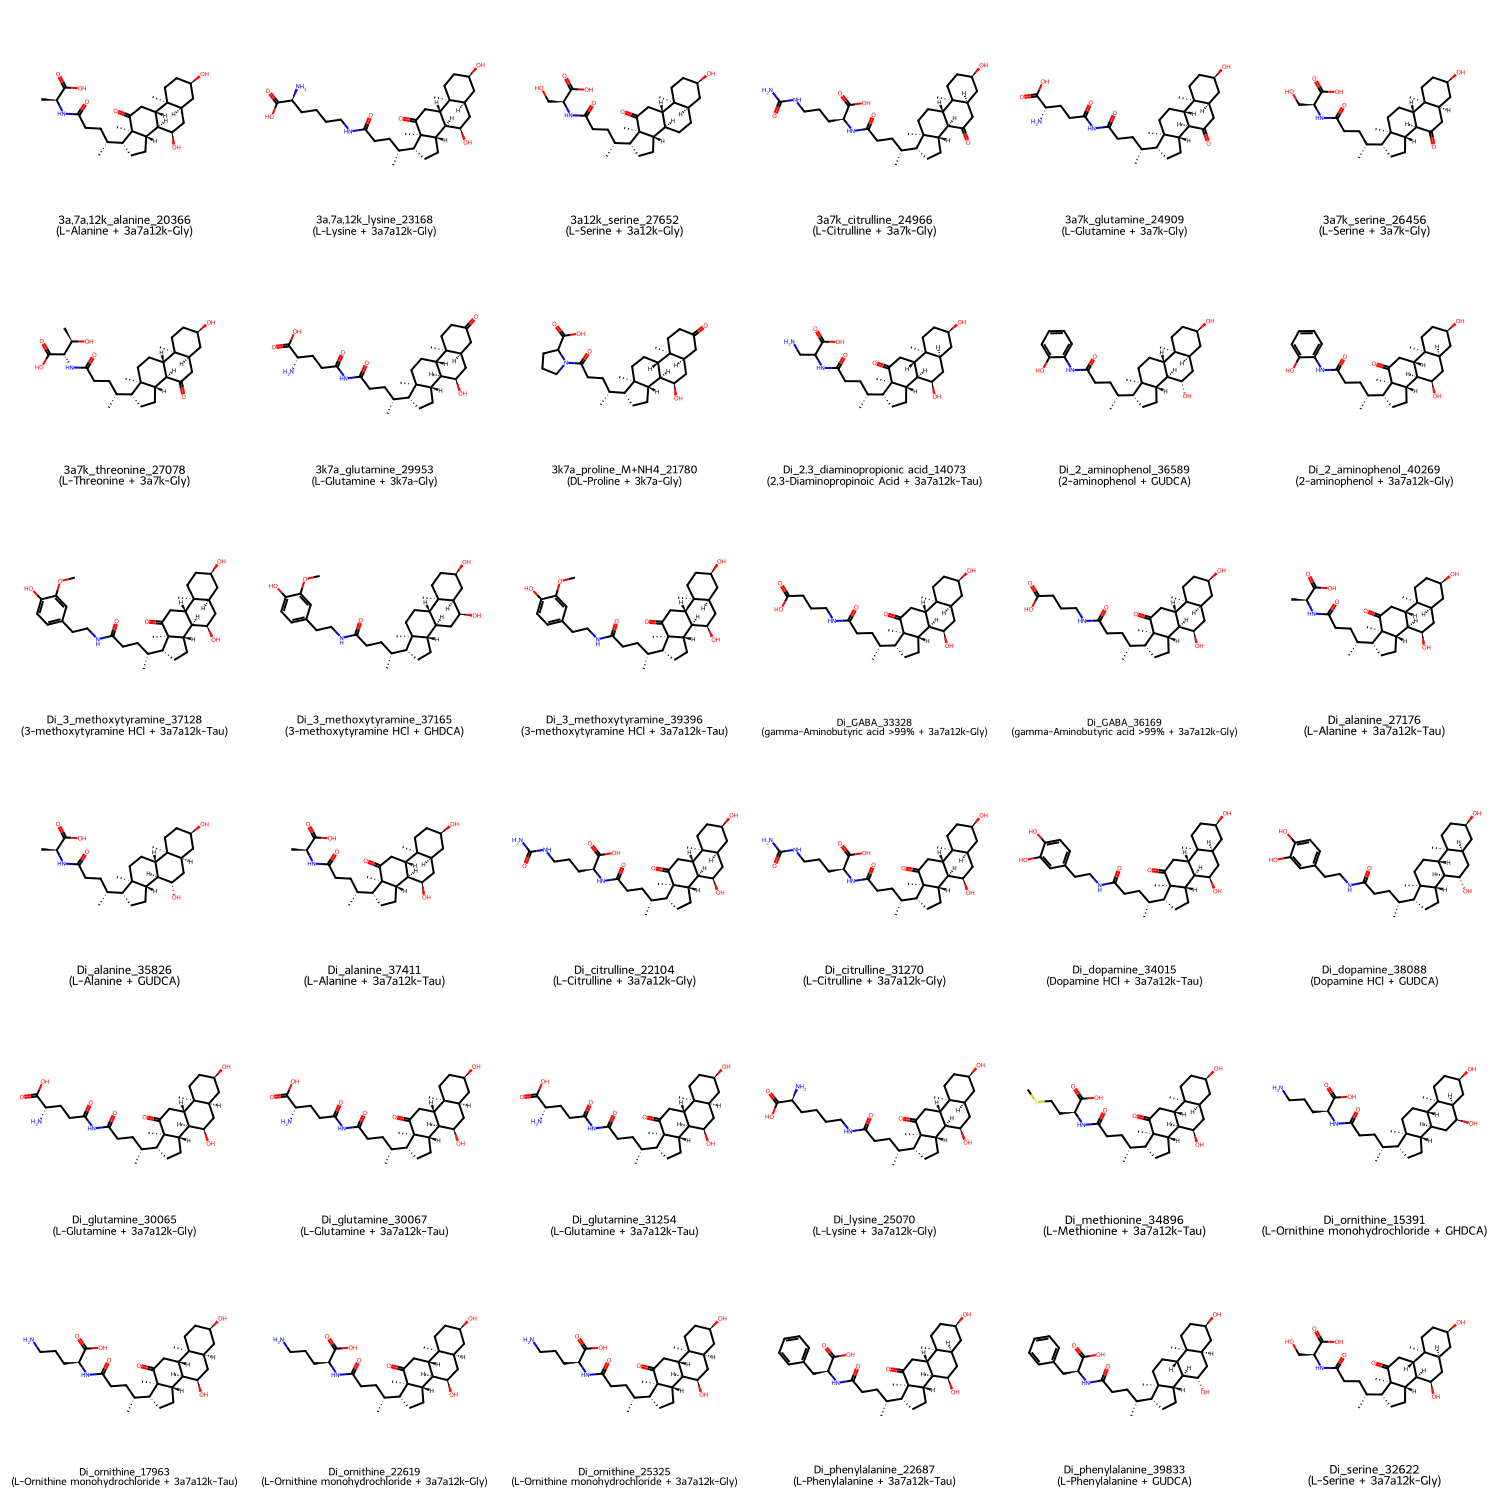

Page 2/3


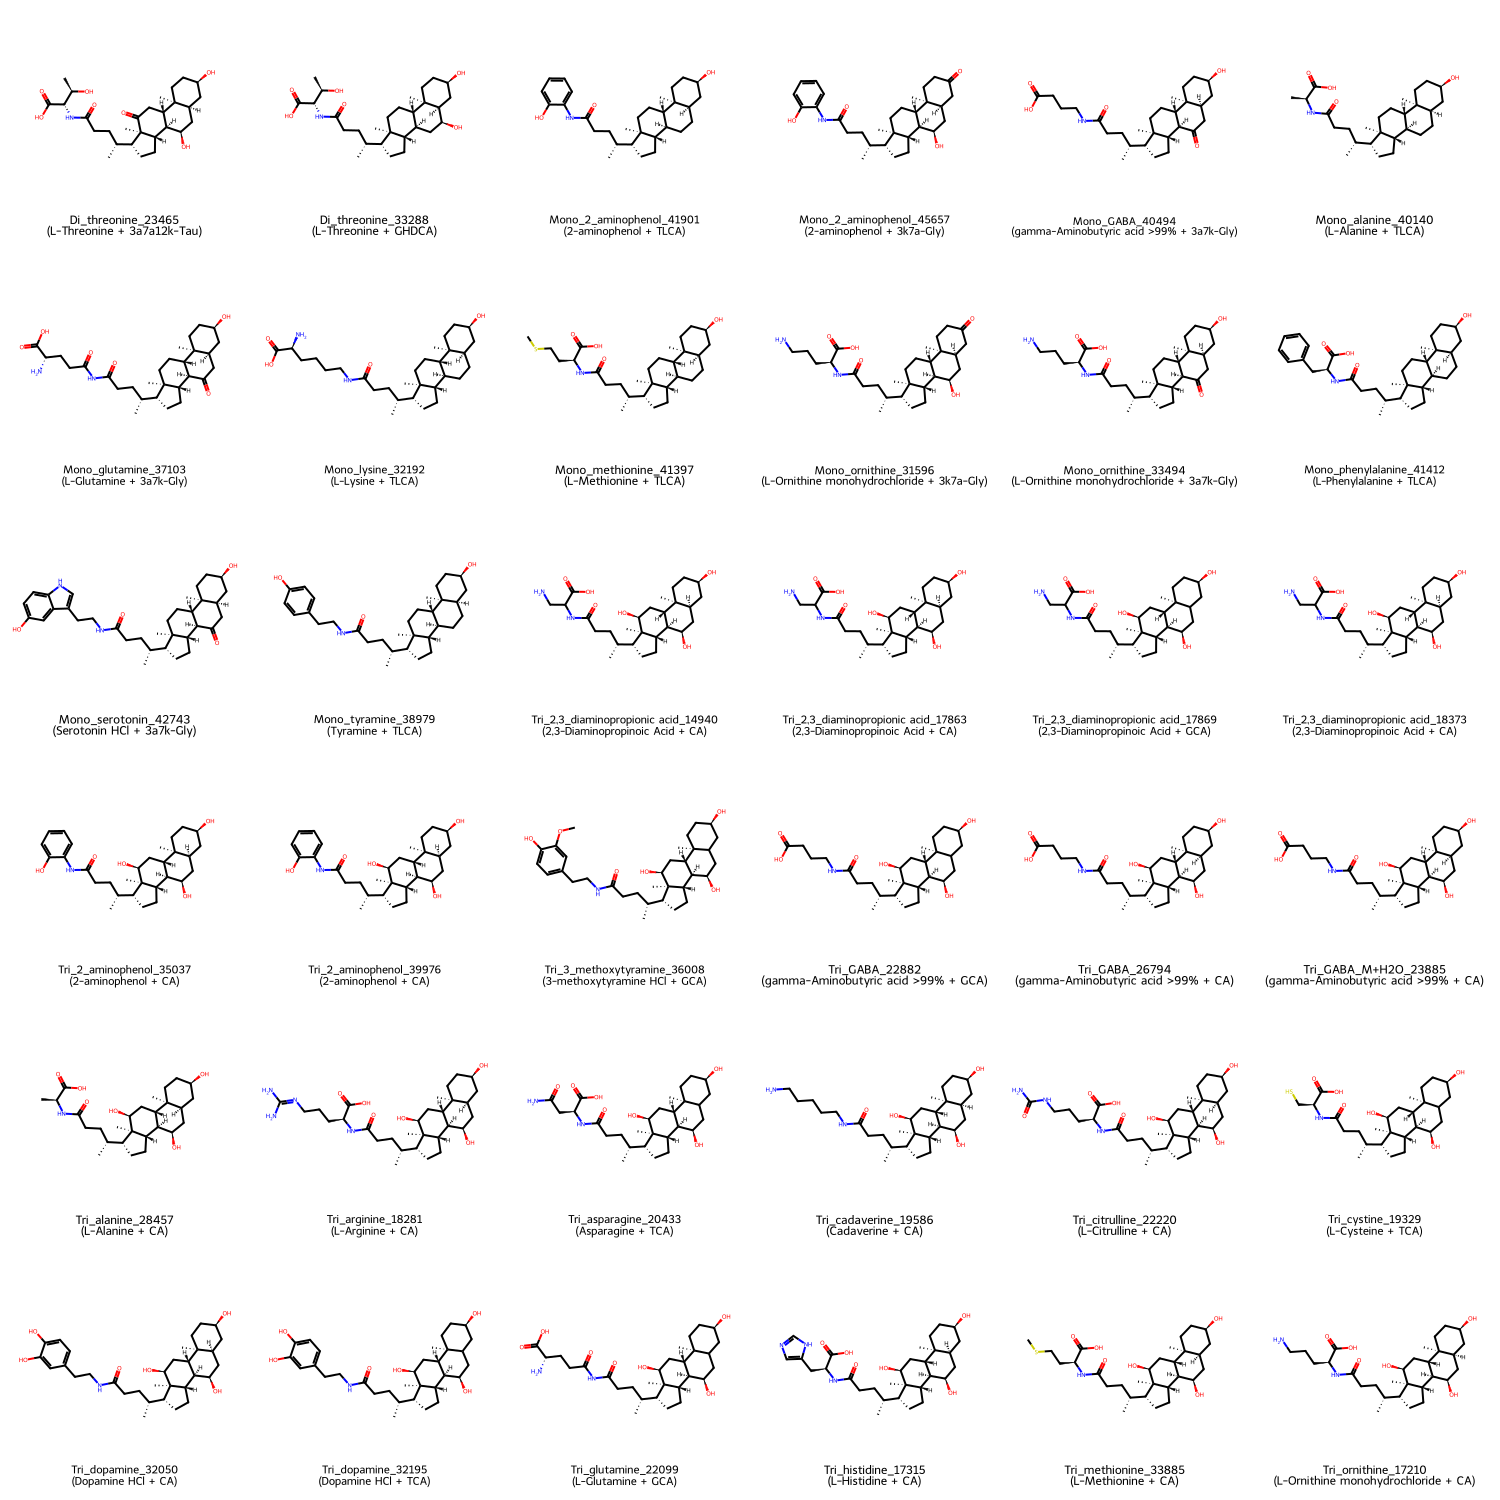

Page 3/3


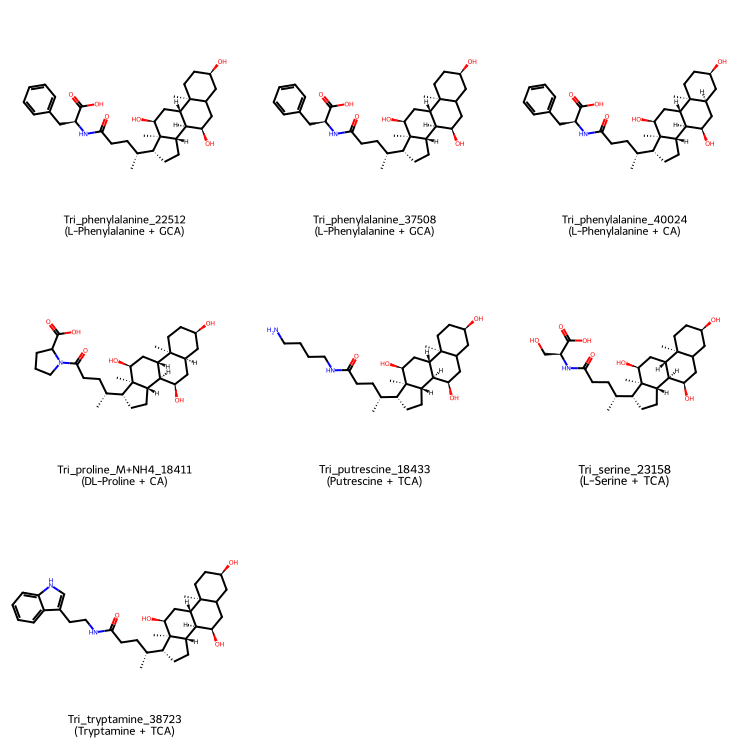

In [32]:
INPUT_XLSX = "swap_enumeration_FINAL.xlsx"
INPUT_CSV  = "swap_enumeration_FINAL.csv"   # fallback if XLSX not present

SUCCESS_ONLY          = True     # keep only rows where Note starts with 'ok'
DEDUP_BY_PRODUCTNAME  = True     # keep only first SMILES per ProductName
APPEND_CONTEXT_TO_LABEL = True   # show "(amine + BA)" on second line
PER_PAGE              = 36       # molecules per page
MOL_SIZE              = (250, 250)
OUT_PREFIX            = "product_gallery"


if os.path.exists(INPUT_XLSX):
    df = pd.read_excel(INPUT_XLSX)
elif os.path.exists(INPUT_CSV):
    df = pd.read_csv(INPUT_CSV)
else:
    raise FileNotFoundError("swap_enumeration_FINAL.xlsx/csv not found.")

# Make sure the columns we need exist
for c in ["ProductName", "Product_SMILES", "Amine_Name", "Parent_BA_Name", "Note"]:
    if c not in df.columns:
        df[c] = np.nan

# --------------------
# Filter rows
# --------------------
def _not_empty(x):
    return (pd.notna(x)) and (str(x).strip() != "")

df2 = df[df["Product_SMILES"].apply(_not_empty)].copy()

if SUCCESS_ONLY:
    df2 = df2[df2["Note"].astype(str).str.lower().str.startswith("ok")]

# Optional: dedup so each ProductName shows once
if DEDUP_BY_PRODUCTNAME:
    df2 = df2.sort_values(["ProductName"]).drop_duplicates(subset=["ProductName"], keep="first")

df2 = df2.reset_index(drop=True)
print(f"[gallery] products to draw: {len(df2)}")

if len(df2) == 0:
    raise SystemExit("No product SMILES to draw after filtering.")

# --------------------
# Build RDKit mols + legends
# --------------------
def make_mol(smiles: str):
    try:
        m = Chem.MolFromSmiles(str(smiles))
        if m is None:
            return None
        m = Chem.RemoveHs(m)
        AllChem.Compute2DCoords(m)
        return m
    except Exception:
        return None

mols = []
legends = []
bad = 0

for _, r in df2.iterrows():
    smi = str(r["Product_SMILES"])
    m = make_mol(smi)
    if m is None:
        bad += 1
        continue
    lbl = str(r["ProductName"])
    if APPEND_CONTEXT_TO_LABEL:
        a = str(r.get("Amine_Name", "") or "").strip()
        b = str(r.get("Parent_BA_Name", "") or "").strip()
        ctx = []
        if a: ctx.append(a)
        if b: ctx.append(b)
        if ctx:
            lbl = f"{lbl}\n({' + '.join(ctx)})"
    mols.append(m); legends.append(lbl)

if not mols:
    raise SystemExit("Nothing drawable (all SMILES failed to parse).")

print(f"[gallery] drawable: {len(mols)} | failed: {bad}")

# --------------------
# Draw in pages
from IPython.display import display, SVG  # display is all we need

n = len(mols)
n_pages = math.ceil(n / PER_PAGE)

for p in range(n_pages):
    i0 = p * PER_PAGE
    i1 = min(n, (p+1) * PER_PAGE)
    chunk_mols = mols[i0:i1]
    chunk_legs = legends[i0:i1]

    # grid geometry: roughly square
    k = len(chunk_mols)
    n_cols = int(math.ceil(math.sqrt(k)))
    n_rows = int(math.ceil(k / n_cols))

    # Option A: raster (PIL) — quick and works everywhere
    img = Draw.MolsToGridImage(
        chunk_mols,
        molsPerRow=n_cols,
        subImgSize=MOL_SIZE,
        legends=chunk_legs,
        useSVG=False
    )
    print(f"Page {p+1}/{n_pages}")
    display(img)



#Histogram of the number of combination possible per product name

- candidate parent is any bile acid we attempt for a given product (free or pre-conjugated), whereas a successful parent is one of those candidates whose route actually yields a valid Product_SMILES.

In [30]:
import plotly.graph_objects as go

FILE   = "swap_enumeration_FINAL.xlsx"
TOP_N  = None   # set e.g. 40 to show top-N products by count; None = show all
HEIGHT = 600    # tweak chart height

df = pd.read_excel(FILE)

# Success = product actually formed
# --- Success masks ---
any_success = (
    df["Product_SMILES"].notna()
    & df["Product_SMILES"].astype(str).str.strip().ne("")
)
new_success = any_success & df["Swap_Source"].astype(str).ne("preconjugate_as_product")

# --- Counts (distinct parents) ---
by_prod_all = df.groupby("ProductName", dropna=False)["Parent_BA_Name"].nunique()
by_prod_any = df[any_success].groupby("ProductName", dropna=False)["Parent_BA_Name"].nunique()
by_prod_new = df[new_success].groupby("ProductName", dropna=False)["Parent_BA_Name"].nunique()

counts = (
    pd.concat([by_prod_all.rename("n_parents_all"),
               by_prod_any.rename("n_parents_success_any"),
               by_prod_new.rename("n_parents_success_new")], axis=1)
      .fillna(0).astype(int).reset_index()
)

# Sort, TOP_N, x_order
counts = counts.sort_values("n_parents_all", ascending=False, kind="mergesort")
if TOP_N is not None:
    counts = counts.head(TOP_N)
x_order = counts["ProductName"].tolist()

# --- Figure with 3 toggles ---
fig = go.Figure()
fig.add_bar(x=counts["ProductName"], y=counts["n_parents_all"],
            name="All candidate parents", text=counts["n_parents_all"],
            textposition="outside", visible=True)
fig.add_bar(x=counts["ProductName"], y=counts["n_parents_success_any"],
            name="Successful (any product)", text=counts["n_parents_success_any"],
            textposition="outside", visible=False)
fig.add_bar(x=counts["ProductName"], y=counts["n_parents_success_new"],
            name="Successful (new chemistry)", text=counts["n_parents_success_new"],
            textposition="outside", visible=False)

fig.update_layout(
    updatemenus=[dict(
        type="buttons", direction="right",
        x=0.5, y=1.15, xanchor="center", yanchor="top",
        buttons=[
            dict(label="All candidate parents", method="update",
                 args=[{"visible":[True, False, False]},
                       {"title":"Bile-acid parents per product — All candidates"}]),
            dict(label="Successful (any product)", method="update",
                 args=[{"visible":[False, True, False]},
                       {"title":"Bile-acid parents per product — Any product"}]),
            dict(label="Successful (new chemistry)", method="update",
                 args=[{"visible":[False, False, True]},
                       {"title":"Bile-acid parents per product — New chemistry only"}]),
        ],
        showactive=True
    )],
    title="Bile-acid parents per product — All candidates",
    xaxis=dict(title="ProductName", categoryorder="array", categoryarray=x_order, tickangle=-45),
    yaxis=dict(title="Count of parent bile acids"),
    barmode="group", height=HEIGHT, margin=dict(l=60, r=30, t=90, b=160),
    dragmode="pan",
)
fig.update_traces(cliponaxis=False)
fig.show()


In [19]:
unsuccessful = swap_enumeration.loc[swap_enumeration["Product_SMILES"].isna()].copy()

# Keep a readable reason column
if "Note" in unsuccessful.columns:
    unsuccessful["Failure_Reason"] = unsuccessful["Note"].fillna("unknown")
else:
    unsuccessful["Failure_Reason"] = "unknown"

# (Optional) limit to the products shown in your current chart order (e.g., top-N)
if "x_order" in globals():
    unsuccessful = unsuccessful[unsuccessful["ProductName"].isin(x_order)]

# Useful subset of columns (only keep those that exist)
cols = [
    "ProductName", "Parent_BA_Name", "Parent_BA_Core_Class",
    "Parent_Preconjugated_Amine", "Swap_Source",
    "Acid_SMILES_Used", "Amine_Name", "Amine_SMILES",
    "Failure_Reason"
]
cols = [c for c in cols if c in unsuccessful.columns]

# Nicely sorted preview
unsuccessful_view = unsuccessful.sort_values(
    by=["ProductName", "Parent_BA_Name", "Swap_Source"]
)[cols]

# Print a summary first
fail_counts = (unsuccessful.groupby("ProductName")
                           .size()
                           .reset_index(name="n_parents_unsuccessful")
                           .sort_values("n_parents_unsuccessful", ascending=False))
print(f"Total unsuccessful parent enumerations: {len(unsuccessful_view)}")
display(fail_counts.head(30).style.hide(axis="index"))

# Detailed rows (trim if huge)
display(unsuccessful_view.head(300).style.hide(axis="index"))

# Save full table if you want
unsuccessful_view.to_excel("unsuccessful_parents.xlsx", index=False)
unsuccessful_view.to_csv("unsuccessful_parents.csv", index=False)
print("Saved: unsuccessful_parents.xlsx and unsuccessful_parents.csv")

# ---------------------------------------------
# (Optional) also add a third bar to your plot: "unsuccessful"
# ---------------------------------------------
# Add a column to counts
if "n_parents_all" in counts.columns and "n_parents_success" in counts.columns:
    counts["n_parents_unsuccessful"] = (
        counts["n_parents_all"] - counts["n_parents_success"]
    ).clip(lower=0)

    # Add third trace + update the buttons
    fig.add_bar(
        x=counts["ProductName"],
        y=counts["n_parents_unsuccessful"],
        name="Unsuccessful parents",
        text=counts["n_parents_unsuccessful"],
        textposition="outside",
        hovertemplate="<b>%{x}</b><br>Unsuccessful parents: %{y}<extra></extra>",
        visible=False,
    )

    # Update the dropdown (3 traces now)
    fig.update_layout(
        updatemenus=[
            dict(
                type="buttons",
                direction="right",
                x=0.5, y=1.15, xanchor="center", yanchor="top",
                buttons=[
                    dict(label="All candidate parents",
                         method="update",
                         args=[{"visible": [True, False, False]},
                               {"title": "Bile-acid parents per product — All candidates"}]),
                    dict(label="Successful parents only",
                         method="update",
                         args=[{"visible": [False, True, False]},
                               {"title": "Bile-acid parents per product — Successful only"}]),
                    dict(label="Unsuccessful parents only",
                         method="update",
                         args=[{"visible": [False, False, True]},
                               {"title": "Bile-acid parents per product — Unsuccessful only"}]),
                ],
                showactive=True
            )
        ]
    )


Total unsuccessful parent enumerations: 3


ProductName,n_parents_unsuccessful
3k12a_lysine_23849,1
Di_unconjugated_34634,1
Tri_glyglycine_20401,1


ProductName,Parent_BA_Name,Parent_BA_Core_Class,Parent_Preconjugated_Amine,Swap_Source,Acid_SMILES_Used,Amine_Name,Amine_SMILES,Failure_Reason
3k12a_lysine_23849,None,None,None,no positional parent,None,L-Lysine,C(CCN)C[C@@H](C(=O)O)N,positional parent required (3k12a) not found
Di_unconjugated_34634,None,None,None,no amine or core,None,None,None,missing amine SMILES or core
Tri_glyglycine_20401,None,None,None,no amine or core,None,None,None,missing amine SMILES or core


Saved: unsuccessful_parents.xlsx and unsuccessful_parents.csv


In [34]:
FA_FILE = "ml_features_conjugation_bsh_FINAL.xlsx"  # or .csv, adjust read_* if needed
fa = pd.read_excel(FA_FILE)

# Keep only bile acids
ba = fa[fa["Dataset"].astype(str).str.casefold() == "bile_acids"].copy()

def norm_core(x):
    if pd.isna(x): return None
    t = str(x).strip().lower()
    if t.startswith("mono"): return "Mono"
    if t.startswith("di"):   return "Di"
    if t.startswith("tri"):  return "Tri"
    return None

ba["Core"] = ba["Bile_Core_Class"].map(norm_core)

# 1) Counts by rows (as listed)
row_counts = (
    ba["Core"].value_counts()
      .reindex(["Mono","Di","Tri"])
      .fillna(0).astype(int)
)

print("Bile acids by core (row counts):")
print(row_counts.to_string())

# 2) Counts by unique structures (dedupe by Standardized_SMILES)
uniq_counts = None
if "Standardized_SMILES" in ba.columns:
    ba_unique = (
        ba.dropna(subset=["Standardized_SMILES"])
          .drop_duplicates("Standardized_SMILES")
    )
    uniq_counts = (
        ba_unique["Core"].value_counts()
          .reindex(["Mono","Di","Tri"])
          .fillna(0).astype(int)
    )
    print("\nBile acids by core (unique structures via Standardized_SMILES):")
    print(uniq_counts.to_string())
else:
    print("\nNote: 'Standardized_SMILES' missing; skipping unique-structure counts.")


Bile acids by core (row counts):
Core
Mono     6
Di      13
Tri      3

Bile acids by core (unique structures via Standardized_SMILES):
Core
Mono     6
Di      13
Tri      3


#HeatMap visualizaion

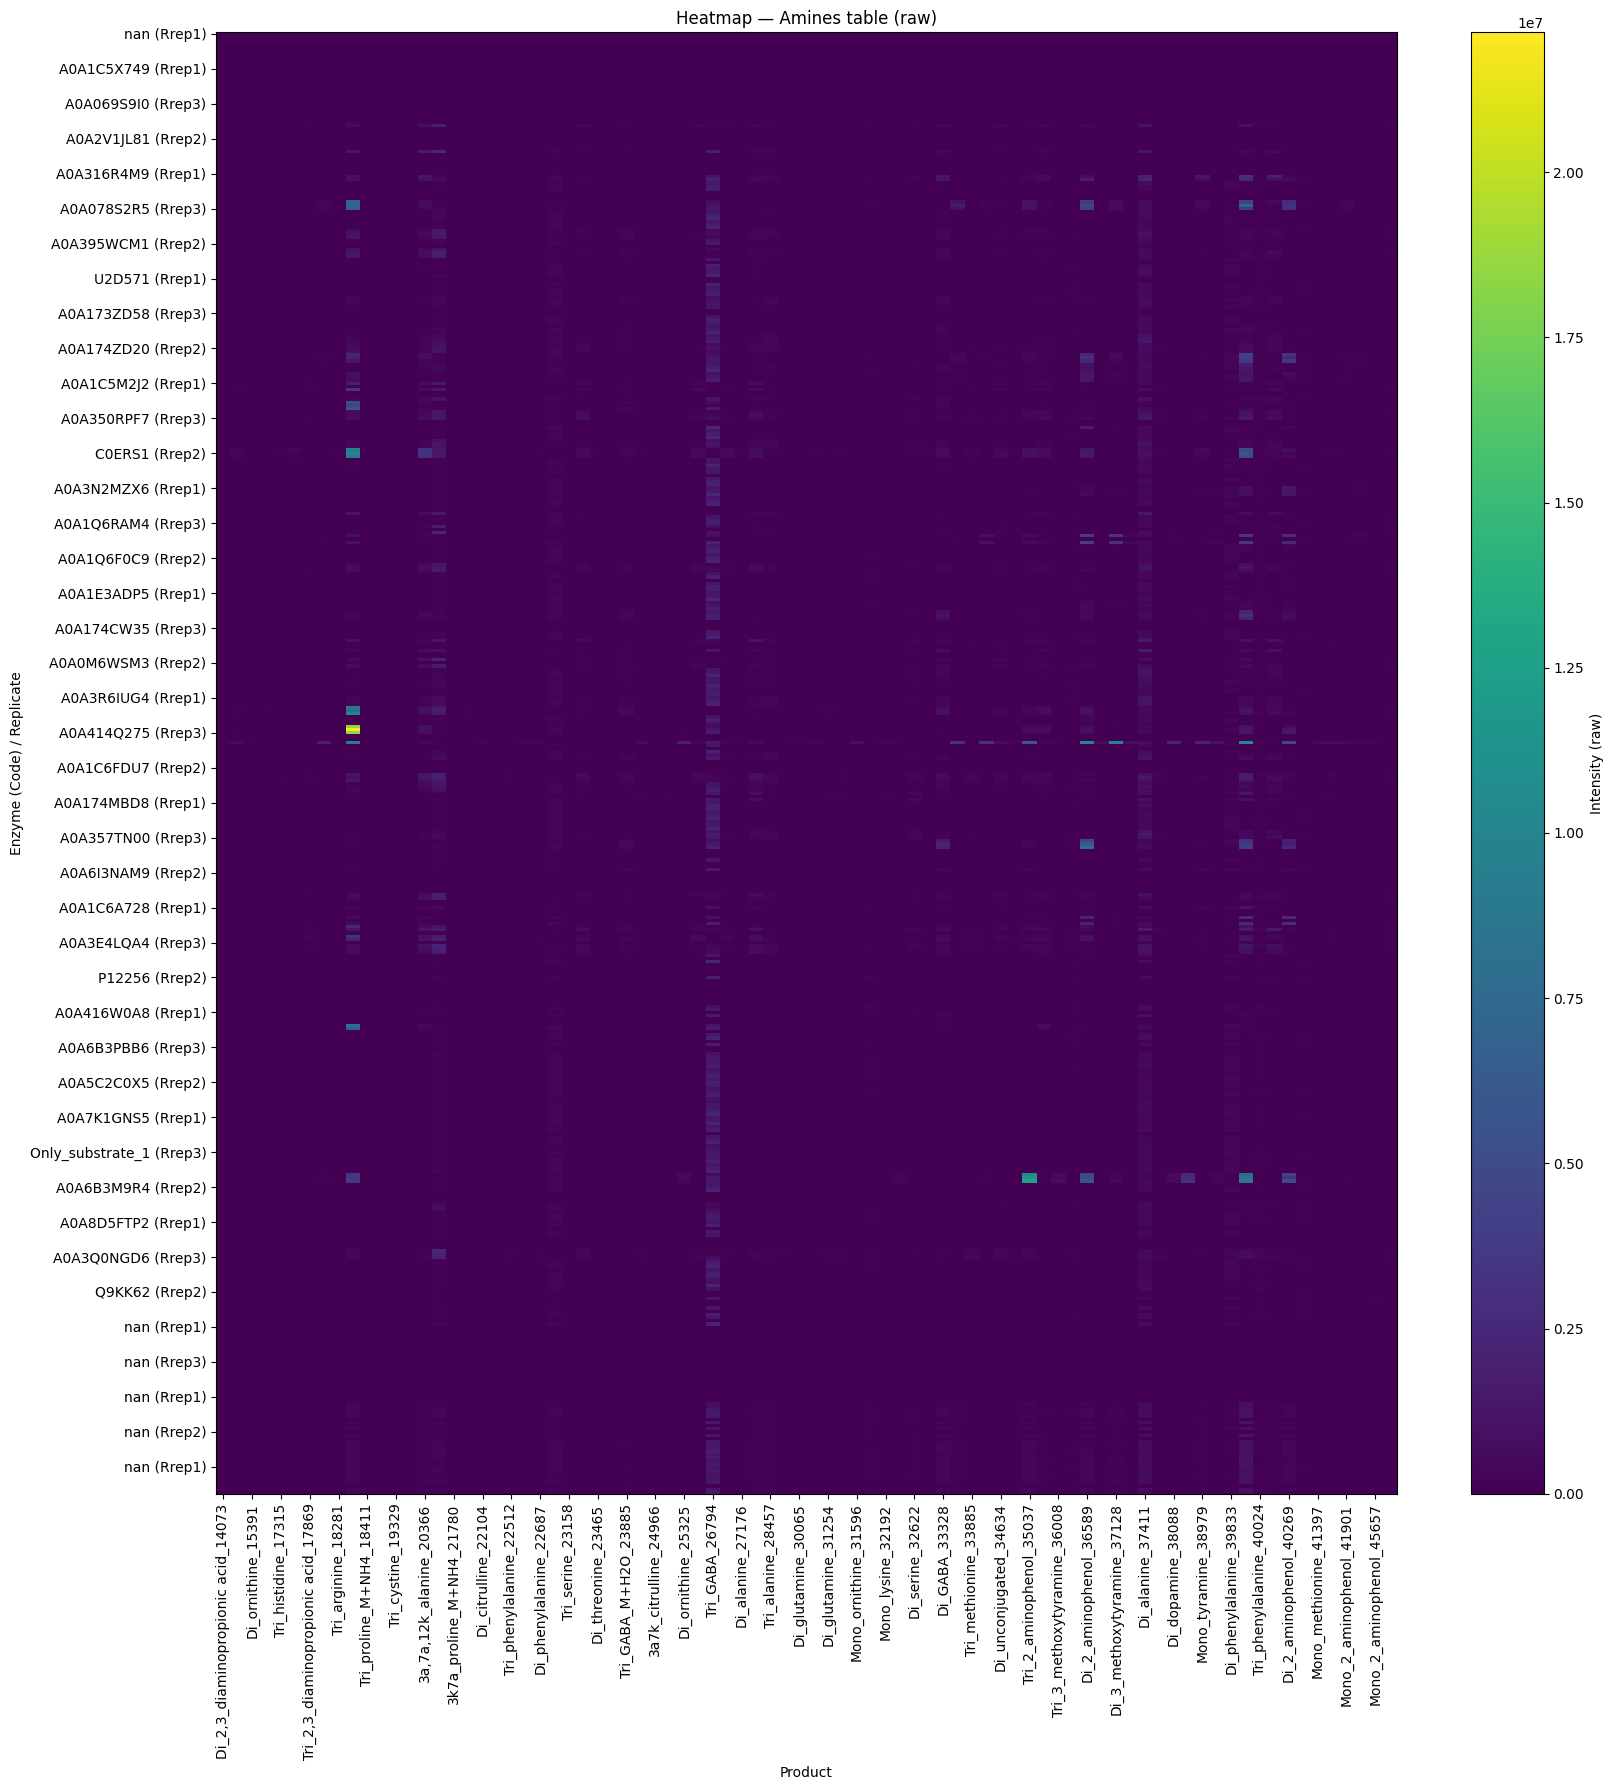

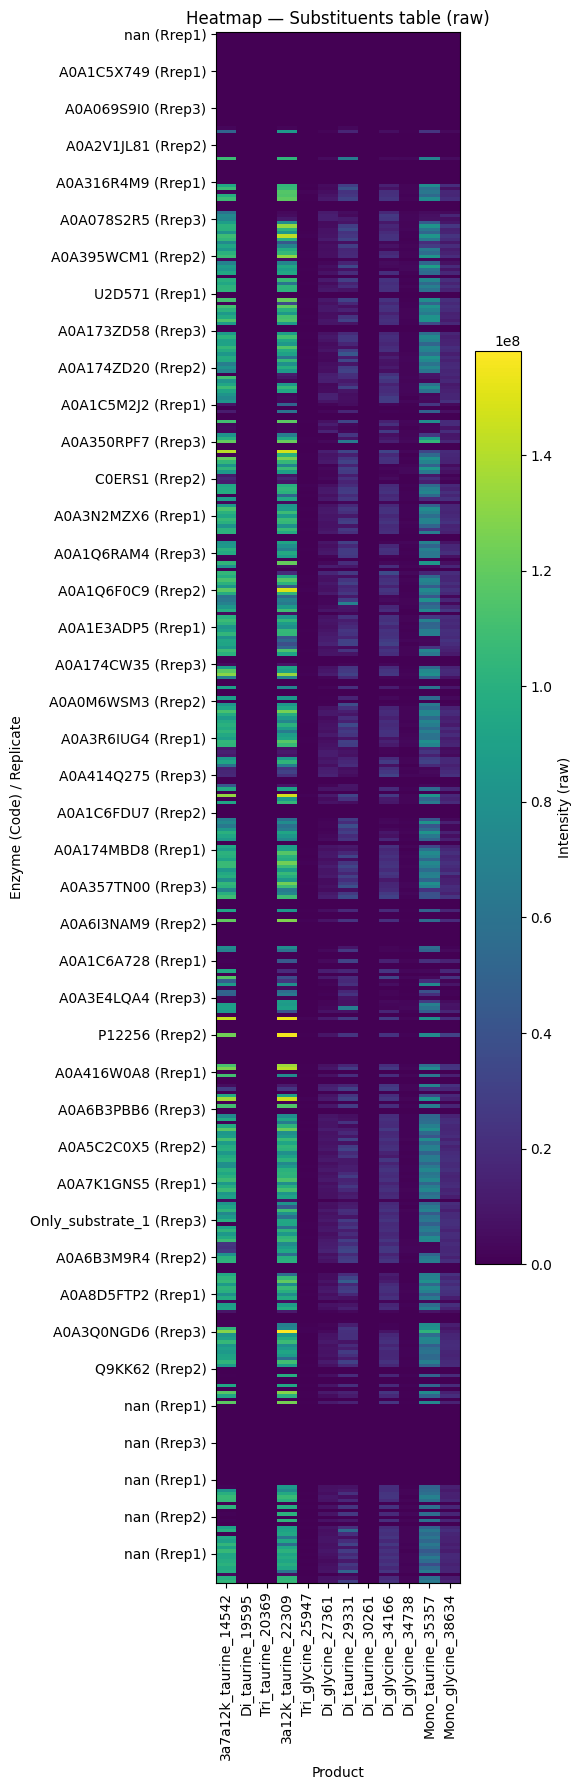

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def _row_labels(df):
    # Use Code (and Replicate if present) to reflect the raw table “as is”
    codes = df["Code"].astype(str).fillna("NA")
    if "Replicate" in df.columns:
        reps = df["Replicate"].astype(str).fillna("NA")
        return [f"{c} (R{r})" for c, r in zip(codes, reps)]
    return codes.tolist()

def _prepare_matrix(df, product_cols):
    # Keep columns in their original order; values as float
    M = df[product_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    return np.ma.masked_invalid(M)  # mask NaNs so imshow leaves them blank

def _plot_heatmap(df, product_cols, title, log_scale=False, vmax=None, show_max_cols=None):
    row_labels = _row_labels(df)
    data = _prepare_matrix(df, product_cols)

    # Optionally limit columns for readability
    cols = product_cols
    if show_max_cols is not None and len(cols) > show_max_cols:
        cols = cols[:show_max_cols]
        data = data[:, :show_max_cols]
        title = f"{title} (showing first {show_max_cols} of {len(product_cols)} columns)"

    # Figure size scales with matrix size (capped for sanity)
    h = min(0.35 * len(row_labels) + 2, 18)
    w = min(0.16 * len(cols) + 4, 24)
    fig, ax = plt.subplots(figsize=(w, h))

    norm = LogNorm(vmin=max(data.min() if np.isfinite(data.min()) else 1e-6, 1e-6),
                   vmax=vmax) if log_scale else None
    im = ax.imshow(data, aspect='auto', interpolation='nearest', norm=norm)

    # Ticks (sparsify to avoid clutter)
    ax.set_yticks(range(len(row_labels)))
    y_step = max(1, len(row_labels) // 40)
    ax.set_yticks(range(0, len(row_labels), y_step))
    ax.set_yticklabels([row_labels[i] for i in range(0, len(row_labels), y_step)])

    ax.set_xticks(range(len(cols)))
    x_step = max(1, len(cols) // 40)
    ax.set_xticks(range(0, len(cols), x_step))
    ax.set_xticklabels([cols[i] for i in range(0, len(cols), x_step)], rotation=90, ha='center')

    ax.set_xlabel("Product")
    ax.set_ylabel("Enzyme (Code) / Replicate")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Intensity (raw)" + (" [log scale]" if log_scale else ""))

    plt.tight_layout()
    plt.show()

# ---- Plot the two raw heatmaps exactly “as is” ----
_plot_heatmap(df_results_amines, product_cols_amines, title="Heatmap — Amines table (raw)", log_scale=False, show_max_cols=None)
_plot_heatmap(df_results_sub,    product_cols_sub,    title="Heatmap — Substituents table (raw)", log_scale=False, show_max_cols=None)


#Turning heatmap values into a table of (Enzyme, ProductName, Intensity)

In [44]:
# --- config ---
META_COLS = ['Code','Replicate','filename']
ENZYME_COL_CANDIDATES = ['Code','Enzyme','enzyme_id']
REPLICATE_COL = 'Replicate'          # set None to skip replicate aggregation
AGG_REP = 'median'                   # 'median' or 'mean'
DO_PER_ENZYME_SCALE = True
MIN_NONZERO_FOR_SCALE = 20
ALIGN_TO_ENUM = True                 # drop products not in swap_enumeration
OUT_PATH = "ipsita_heatmap_long.xlsx"

def _pick_col(df, cands):
    for c in cands:
        if c in df.columns: return c
    # loose match fallback
    for c in df.columns:
        if any(re.sub(r'[^a-z0-9]+','', k.lower()) in re.sub(r'[^a-z0-9]+','', c.lower()) for k in cands):
            return c
    return None

def _melt(df, product_cols, enzyme_col):
    id_vars = [c for c in META_COLS if c in df.columns]
    m = df.loc[:, id_vars + product_cols].copy()
    long = m.melt(id_vars=id_vars, value_vars=product_cols,
                  var_name="ProductName", value_name="Intensity")
    if enzyme_col not in long.columns:
        raise KeyError(f"Need enzyme column '{enzyme_col}' in melted table.")
    long = long.rename(columns={enzyme_col: "Enzyme"})
    long["Enzyme"] = long["Enzyme"].astype(str)
    long["ProductName"] = long["ProductName"].astype(str)
    long["Intensity"] = pd.to_numeric(long["Intensity"], errors="coerce").fillna(0.0)
    return long[["Enzyme","ProductName","Intensity"] + ([REPLICATE_COL] if REPLICATE_COL in long.columns else [])]

def _scale_per_enzyme(df_long):
    d = df_long.copy()
    # median of nonzero intensities per enzyme
    med = (d.groupby("Enzyme")["Intensity"]
             .apply(lambda s: np.median(s[s>0]) if (s>0).sum() >= MIN_NONZERO_FOR_SCALE else np.nan))
    global_med = np.nanmedian(d.loc[d["Intensity"]>0, "Intensity"]) if (d["Intensity"]>0).any() else np.nan
    scales = (global_med / med).rename("scale")
    d = d.merge(scales, left_on="Enzyme", right_index=True, how="left")
    d["Intensity"] = d["Intensity"] * d["scale"].fillna(1.0)
    return d.drop(columns=["scale"])

def build_labels_df(df_results_amines, df_results_sub, swap_enumeration=None):
    # figure out enzyme col for each (they can differ)
    enz_A = _pick_col(df_results_amines, ENZYME_COL_CANDIDATES)
    enz_B = _pick_col(df_results_sub,    ENZYME_COL_CANDIDATES)
    if enz_A is None or enz_B is None:
        raise KeyError("Cannot find enzyme column in one of the heatmap tables.")

    prod_A = [c for c in df_results_amines.columns if c not in META_COLS]
    prod_B = [c for c in df_results_sub.columns    if c not in META_COLS]

    long_A = _melt(df_results_amines, prod_A, enzyme_col=enz_A)
    long_B = _melt(df_results_sub,    prod_B, enzyme_col=enz_B)
    labels = pd.concat([long_A, long_B], ignore_index=True)

    # optional per-enzyme scaling
    if DO_PER_ENZYME_SCALE:
        labels = _scale_per_enzyme(labels)

    # replicate aggregation
    if REPLICATE_COL and REPLICATE_COL in (set(df_results_amines.columns) | set(df_results_sub.columns)):
        # melt kept Replicate in columns earlier; aggregate now
        if AGG_REP == "median":
            labels = (labels.groupby(["Enzyme","ProductName"], as_index=False)["Intensity"].median())
        else:
            labels = (labels.groupby(["Enzyme","ProductName"], as_index=False)["Intensity"].mean())
    else:
        labels = (labels.groupby(["Enzyme","ProductName"], as_index=False)["Intensity"].mean())

    # optional: align to enumeration
    if ALIGN_TO_ENUM and isinstance(swap_enumeration, pd.DataFrame) and "ProductName" in swap_enumeration.columns:
        valid = set(swap_enumeration["ProductName"].dropna().astype(str).unique())
        before = labels["ProductName"].nunique()
        labels = labels[labels["ProductName"].astype(str).isin(valid)].copy()
        after  = labels["ProductName"].nunique()
        if before != after:
            print(f"[align] products: {before} → {after} (matched enumeration)")

    # save once
    labels.to_csv(OUT_PATH, index=False)
    print(f"[OK] Saved labels → {OUT_PATH}")
    print(f"rows={len(labels)} | enzymes={labels['Enzyme'].nunique()} | products={labels['ProductName'].nunique()}")
    return labels

# ---- run it (uses existing dfs in memory) ----
labels_df = build_labels_df(df_results_amines, df_results_sub,
                            swap_enumeration=swap_enumeration if 'swap_enumeration' in globals() else None)

# convenient aliases some cells expect
labels_long = labels_df.copy()
heat_long   = labels_df.copy()


[OK] Saved labels → ipsita_heatmap_long.xlsx
rows=12690 | enzymes=135 | products=94


Note that: 'A0A1Y4QH48', 'Pencillin_amidase', 'nan' don't have associated embeddings.

* need to compute them/ask where Pencillin_amidase is coming from since it has no associated ID
 perhaps they included other embeddings that I am not aware ofgoing off the fasta file Anna sent me

In [40]:
labels_df

,Enzyme,ProductName,Intensity
0,A0A069S9I0,"3a,7a,12k_alanine_20366",0.000000
1,A0A069S9I0,"3a,7a,12k_lysine_23168",0.000000
2,A0A069S9I0,3a12k_serine_27652,0.000000
3,A0A069S9I0,3a12k_taurine_22309,91030.702658
4,A0A069S9I0,3a7a12k_taurine_14542,64942.924120
...,...,...,...
12685,nan,Tri_proline_M+NH4_18411,0.000000
12686,nan,Tri_putrescine_18433,0.000000
12687,nan,Tri_serine_23158,0.000000
12688,nan,Tri_taurine_20369,0.000000


#Loading Embeddings
* currently working with prot5 embeddings





In [41]:
import re, h5py, numpy as np, pandas as pd
from difflib import get_close_matches

H5_PATH = "Seqs_list_total.h5"  # your H5 with per-sequence embeddings

# If heat_long isn't in memory, load it from disk:
try:
    heat_long
except NameError:
    heat_long = pd.read_csv("ipsita_heatmap_long.csv")

assert "Enzyme" in heat_long.columns, "heat_long must have an 'Enzyme' column."

# ---- helpers to enumerate H5 datasets ----
def collect_h5_datasets(h5_path):
    paths = []
    with h5py.File(h5_path, "r") as f:
        def visit(name, obj):
            if isinstance(obj, h5py.Dataset):
                paths.append(name)
        f.visititems(visit)
    return paths

def norm_key(s: str) -> str:
    # Uppercase, alphanumeric only (robust matching)
    return re.sub(r"[^A-Za-z0-9]", "", str(s)).upper()

def last_token(code: str) -> str:
    # Take suffix after the last underscore (e.g., 'Lacto_A0A5C2C1U8' -> 'A0A5C2C1U8')
    return str(code).split("_")[-1]

# ---- scan H5 once and index by normalized base name ----
all_paths = collect_h5_datasets(H5_PATH)
if not all_paths:
    raise RuntimeError(f"No datasets found in {H5_PATH}.")

bases = [p.rsplit("/", 1)[-1] for p in all_paths]       # final path component only
norm_bases = [norm_key(b) for b in bases]
normbase_to_path = {}
for base, normb, full in zip(bases, norm_bases, all_paths):
    normbase_to_path.setdefault(normb, full)             # first occurrence wins

all_norm_bases = list(normbase_to_path.keys())

def pick_contains_match(tok_norm: str):
    hits = [b for b in all_norm_bases if tok_norm in b or b in tok_norm]
    if not hits: return None
    hits = sorted(hits, key=len)  # shortest base first (often the bare accession)
    return normbase_to_path[hits[0]]

def pick_fuzzy_match(tok_norm: str, cutoff=0.92):
    cand = get_close_matches(tok_norm, all_norm_bases, n=1, cutoff=cutoff)
    return (normbase_to_path[cand[0]] if cand else None)

def match_dataset_for_enzyme(enzyme_id: str) -> str | None:
    """
    Try multiple strategies:
      1) exact match on full normalized enzyme string;
      2) exact match on last-token (accession-like);
      3) contains fallback;
      4) fuzzy fallback.
    Return full H5 dataset path or None.
    """
    full_norm = norm_key(enzyme_id)
    tok_norm  = norm_key(last_token(enzyme_id))

    # 1) exact on full norm
    if full_norm in normbase_to_path:
        return normbase_to_path[full_norm]
    # 2) exact on last token
    if tok_norm in normbase_to_path:
        return normbase_to_path[tok_norm]
    # 3) contains
    p = pick_contains_match(tok_norm)
    if p: return p
    # 4) fuzzy
    return pick_fuzzy_match(tok_norm, cutoff=0.92)

def fetch_and_pool(h5_path, full_path):
    with h5py.File(h5_path, "r") as f:
        arr = np.array(f[full_path])
    # mean-pool per-residue to a single vector
    if arr.ndim == 2 and arr.shape[0] > 1:
        arr = arr.mean(axis=0)
    elif arr.ndim == 2 and arr.shape[0] == 1:
        arr = arr[0]
    elif arr.ndim > 2:
        arr = arr.reshape(arr.shape[-1])
    return arr.astype(np.float32)

# ---- do the matching for enzymes present in heat_long ----
enz_ids = sorted(heat_long["Enzyme"].astype(str).unique().tolist())
rows, unmatched = [], []
for eid in enz_ids:
    path = match_dataset_for_enzyme(eid)
    if path is None:
        unmatched.append(eid); continue
    try:
        vec = fetch_and_pool(H5_PATH, path)
        rows.append((eid, path, vec, int(vec.shape[-1])))
    except Exception as e:
        print(f"[Warn] failed to read {eid} at {path}: {e}")

if not rows:
    raise RuntimeError("No embeddings loaded—check H5 structure and enzyme naming.")

df_enz = pd.DataFrame(rows, columns=["Enzyme", "h5_path", "Embedding", "dim"])
E = np.stack(df_enz["Embedding"].values, axis=0).astype(np.float32)
d_prot = E.shape[1]
enzyme2idx = {eid: i for i, eid in enumerate(df_enz["Enzyme"].tolist())}

print(f"[OK] Embedding matrix: {E.shape} (d_prot={d_prot})")
print(f"[Match] {len(df_enz)} matched / {len(enz_ids)} enzymes in heat_long.")
if unmatched[:10]:
    print("[Unmatched] examples:", unmatched[:10])

# (Optional) save embeddings for reuse
np.save("enzyme_embeddings.npy", {row.Enzyme: row.Embedding for _, row in df_enz.iterrows()})
emb_cols = [f"enz_{i}" for i in range(d_prot)]
pd.concat(
    [df_enz[["Enzyme"]].reset_index(drop=True),
     pd.DataFrame(E, columns=emb_cols)],
    axis=1
).to_csv("enzyme_embeddings.csv", index=False)
print("Saved: enzyme_embeddings.npy (dict) and enzyme_embeddings.csv (flat table)")


[OK] Embedding matrix: (132, 1024) (d_prot=1024)
[Match] 132 matched / 135 enzymes in heat_long.
[Unmatched] examples: ['A0A1Y4QH48', 'Pencillin_amidase', 'nan']
Saved: enzyme_embeddings.npy (dict) and enzyme_embeddings.csv (flat table)


In [43]:
df_enz.head()

,Enzyme,h5_path,Embedding,dim
0,A0A069S9I0,cluster54_A0A069S9I0,"[-0.017257635, 0.04989724, 0.03538562, 0.00854...",1024
1,A0A078S2R5,cluster23_A0A078S2R5,"[-0.010787812, 0.05008991, 0.03887677, 0.00458...",1024
2,A0A096B1U0,cluster183_A0A096B1U0,"[-0.057331573, 0.025941156, 0.06507717, 0.0291...",1024
3,A0A096DGB7,cluster245_A0A096DGB7,"[-0.019923376, 0.024629124, 0.024821218, 0.018...",1024
4,A0A096KTH7,cluster10_A0A096KTH7,"[-0.045196902, 0.010763844, 0.041411456, 0.022...",1024


The files generated with this code  will now be used for the building of the model -BSH_conjugaiton model.py